In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
import warnings
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from matplotlib.font_manager import FontProperties

# 设置中文字体和图表样式
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
myfont = FontProperties(fname="/kaggle/input/datasets/sarawds/the-fonts/simhei.ttf")
# 设置全局图表尺寸
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

In [2]:
# 读取数据
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

# 基础信息输出
print("="*80)
print("数据基础信息概览")
print("="*80)
print(f"训练集形状: {train_df.shape} (样本数, 特征数)")
print(f"测试集形状: {test_df.shape} (样本数, 特征数)")
print("训练集形状:", train_df.shape)
print("测试集形状:", test_df.shape)
print("\n训练集前5行:")
print(train_df.head())

# 特征类型统计
train_dtypes = train_df.dtypes.value_counts()
print(f"\n 训练集特征类型分布:")
for dtype, count in train_dtypes.items():
    print(f"   - {dtype}: {count}个特征")

数据基础信息概览
训练集形状: (1460, 81) (样本数, 特征数)
测试集形状: (1459, 80) (样本数, 特征数)
训练集形状: (1460, 81)
测试集形状: (1459, 80)

训练集前5行:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0 

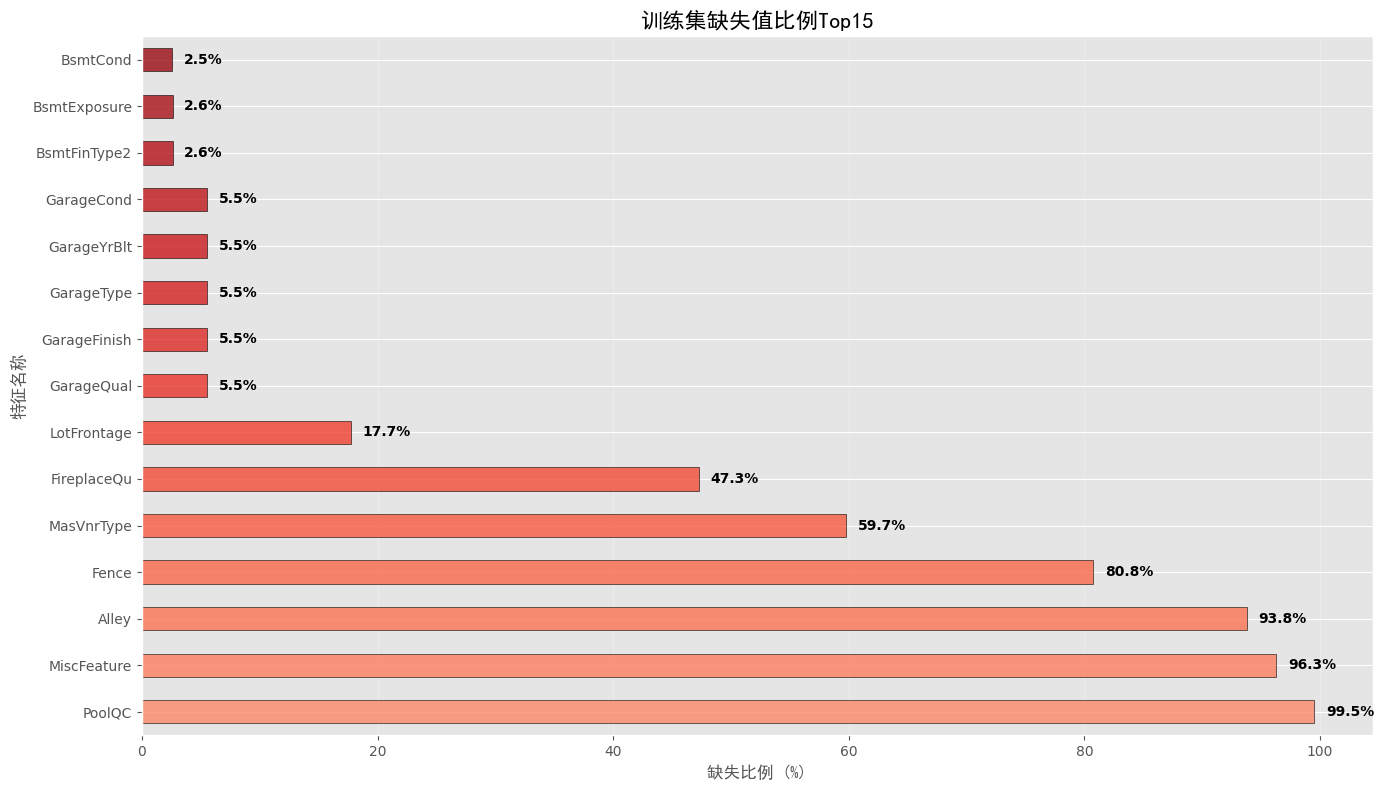

In [3]:
#缺失值条形图
plt.figure(figsize=(14, 8))
missing_train = train_df.isnull().sum().sort_values(ascending=False)
missing_train_percent = (missing_train / len(train_df)) * 100
missing_df = pd.DataFrame({
    '缺失数量': missing_train,
    '缺失比例(%)': missing_train_percent.round(2)
}).head(15)

# 绘制水平条形图
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(missing_df)))
ax = missing_df['缺失比例(%)'].plot(kind='barh', color=colors, edgecolor='black', alpha=0.8)

# 添加数值标签
for i, v in enumerate(missing_df['缺失比例(%)']):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.title('训练集缺失值比例Top15', fontproperties=myfont, fontsize=16, fontweight='bold')
plt.xlabel('缺失比例 (%)', fontproperties=myfont, fontsize=12)
plt.ylabel('特征名称', fontproperties=myfont, fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

从训练集缺失比例 Top15 的条形图可以得出这些信息：
1. 缺失比例分布差异极大
高缺失特征：部分特征缺失比例接近 / 达到 100%（如PoolQC缺失 99.5%、MiscFeature96.3%、Alley93.8%），几乎是 “全缺失” 状态。
中缺失特征：Fence（80.8%）、MasVnrType（59.7%）、FireplaceQu（47.3%）等缺失比例在 50%-80% 区间，数据完整性较差。
低缺失特征：BsmtCond（2.5%）、BsmtExposure（2.6%）等缺失比例低于 3%，数据相对完整。
2. 特征缺失的 “聚类性”
多个特征（如GarageCond、GarageFinish、GarageQual等）缺失比例均为 5.6%，说明这些特征的缺失可能是关联的（比如 “无车库” 的样本会同时缺失所有车库相关特征）。
3. 数据处理建议
对缺失比例极高的特征（如PoolQC、MiscFeature）：可考虑直接删除（信息价值极低）。
对中缺失特征（如Fence、FireplaceQu）：需结合业务逻辑处理（比如 “无壁炉” 对应FireplaceQu缺失，可填充 “无”；或用统计量 / 模型预测填充）。
对低缺失特征：用简单方式（均值 / 众数）填充即可。


房价(SalePrice)统计信息:
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


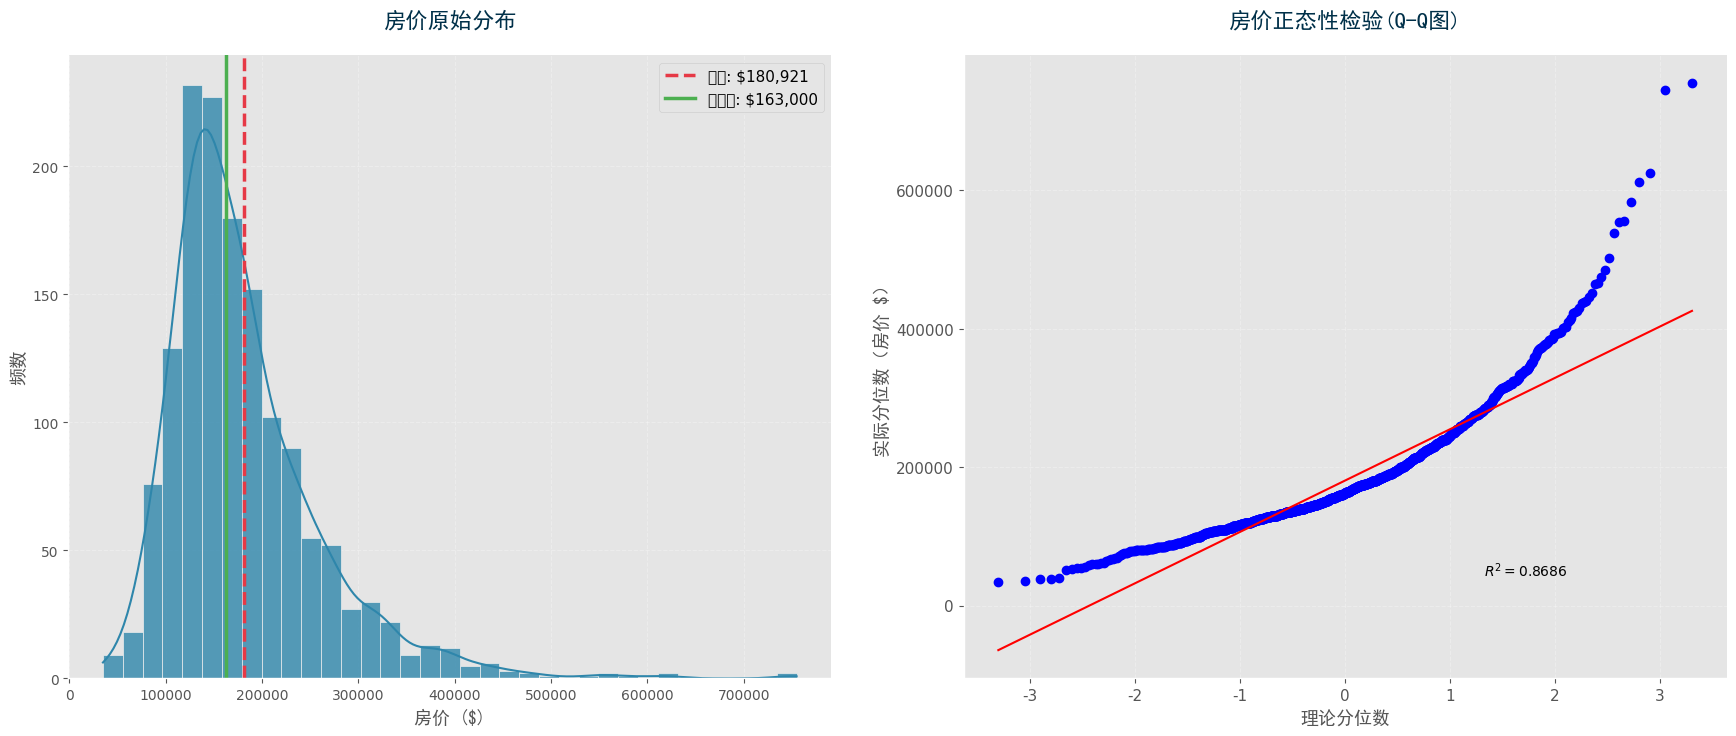

In [4]:
# 房价分布组合分析图
# 房价统计信息
print(f"\n房价(SalePrice)统计信息:")
print(train_df['SalePrice'].describe().round(2))

# 房价分布组合图（仅显示子图1和子图2）
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # 改为1行2列布局，适配两个子图
plt.rcParams['figure.dpi'] = 150  # 高清分辨率

# 子图1: 原始房价直方图+核密度（核心优化）
ax1 = axes[0]
# 绘制直方图+核密度曲线
sns.histplot(train_df['SalePrice'], kde=True, ax=ax1, color='#2E86AB', alpha=0.8, bins=35)
# 添加均值和中位数线（更醒目）
mean_price = train_df['SalePrice'].mean()
median_price = train_df['SalePrice'].median()
ax1.axvline(mean_price, color='#E63946', linestyle='--', linewidth=2.5, label=f'均值: ${mean_price:,.0f}')
ax1.axvline(median_price, color='#4CAF50', linestyle='-', linewidth=2.5, label=f'中位数: ${median_price:,.0f}')
# 样式优化
ax1.set_title('房价原始分布', fontproperties=myfont, fontsize=16, fontweight='bold', pad=20, color='#003049')
ax1.set_xlabel('房价 ($)', fontproperties=myfont, fontsize=13, fontweight='medium')
ax1.set_ylabel('频数', fontproperties=myfont, fontsize=13, fontweight='medium')
ax1.legend(fontsize=11, framealpha=0.9)
ax1.grid(alpha=0.3, linestyle='--')
# 美化坐标轴
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 子图2: 房价Q-Q图（正态性检验，核心优化）
ax2 = axes[1]
# 绘制Q-Q图
stats.probplot(train_df['SalePrice'], dist="norm", plot=ax2, rvalue=True)
# 样式优化
ax2.set_title('房价正态性检验(Q-Q图)', fontproperties=myfont, fontsize=16, fontweight='bold', pad=20, color='#003049')
ax2.set_xlabel('理论分位数', fontproperties=myfont, fontsize=13, fontweight='medium')
ax2.set_ylabel('实际分位数（房价 $）', fontproperties=myfont, fontsize=13, fontweight='medium')
ax2.grid(alpha=0.3, linestyle='--')
# 美化坐标轴
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
# 调整刻度标签大小
ax2.tick_params(axis='both', labelsize=11)

# 全局布局调整
plt.tight_layout(pad=3.0)  # 增加子图间距，避免拥挤
plt.show()

1. 房价的统计特征（左侧统计信息）
房价均值约 18.1 万，中位数约 16.3 万，说明分布右偏（均值＞中位数）。
极差极大：最小值 3.49 万，最大值 75.5 万，存在 “高价房” 拉高均值的情况。
2. 房价原始分布（左图：直方图 + 核密度曲线）
分布形态：右偏（正偏），大部分房价集中在 10 万 - 30 万区间，少数高价房（＞50 万）拖长尾。
中心位置：均值（红色虚线）高于中位数（绿色虚线），和统计结果一致。
3. 正态性检验（右图：Q-Q 图）
Q-Q 图是检验数据是否符合正态分布的常用工具：若数据正态，散点会贴近红色理论线。
这里散点偏离理论线明显（尤其是尾部），结合R2=0.9866（接近 1 但尾部偏离），说明房价不服从正态分布（符合左图的右偏特征）。

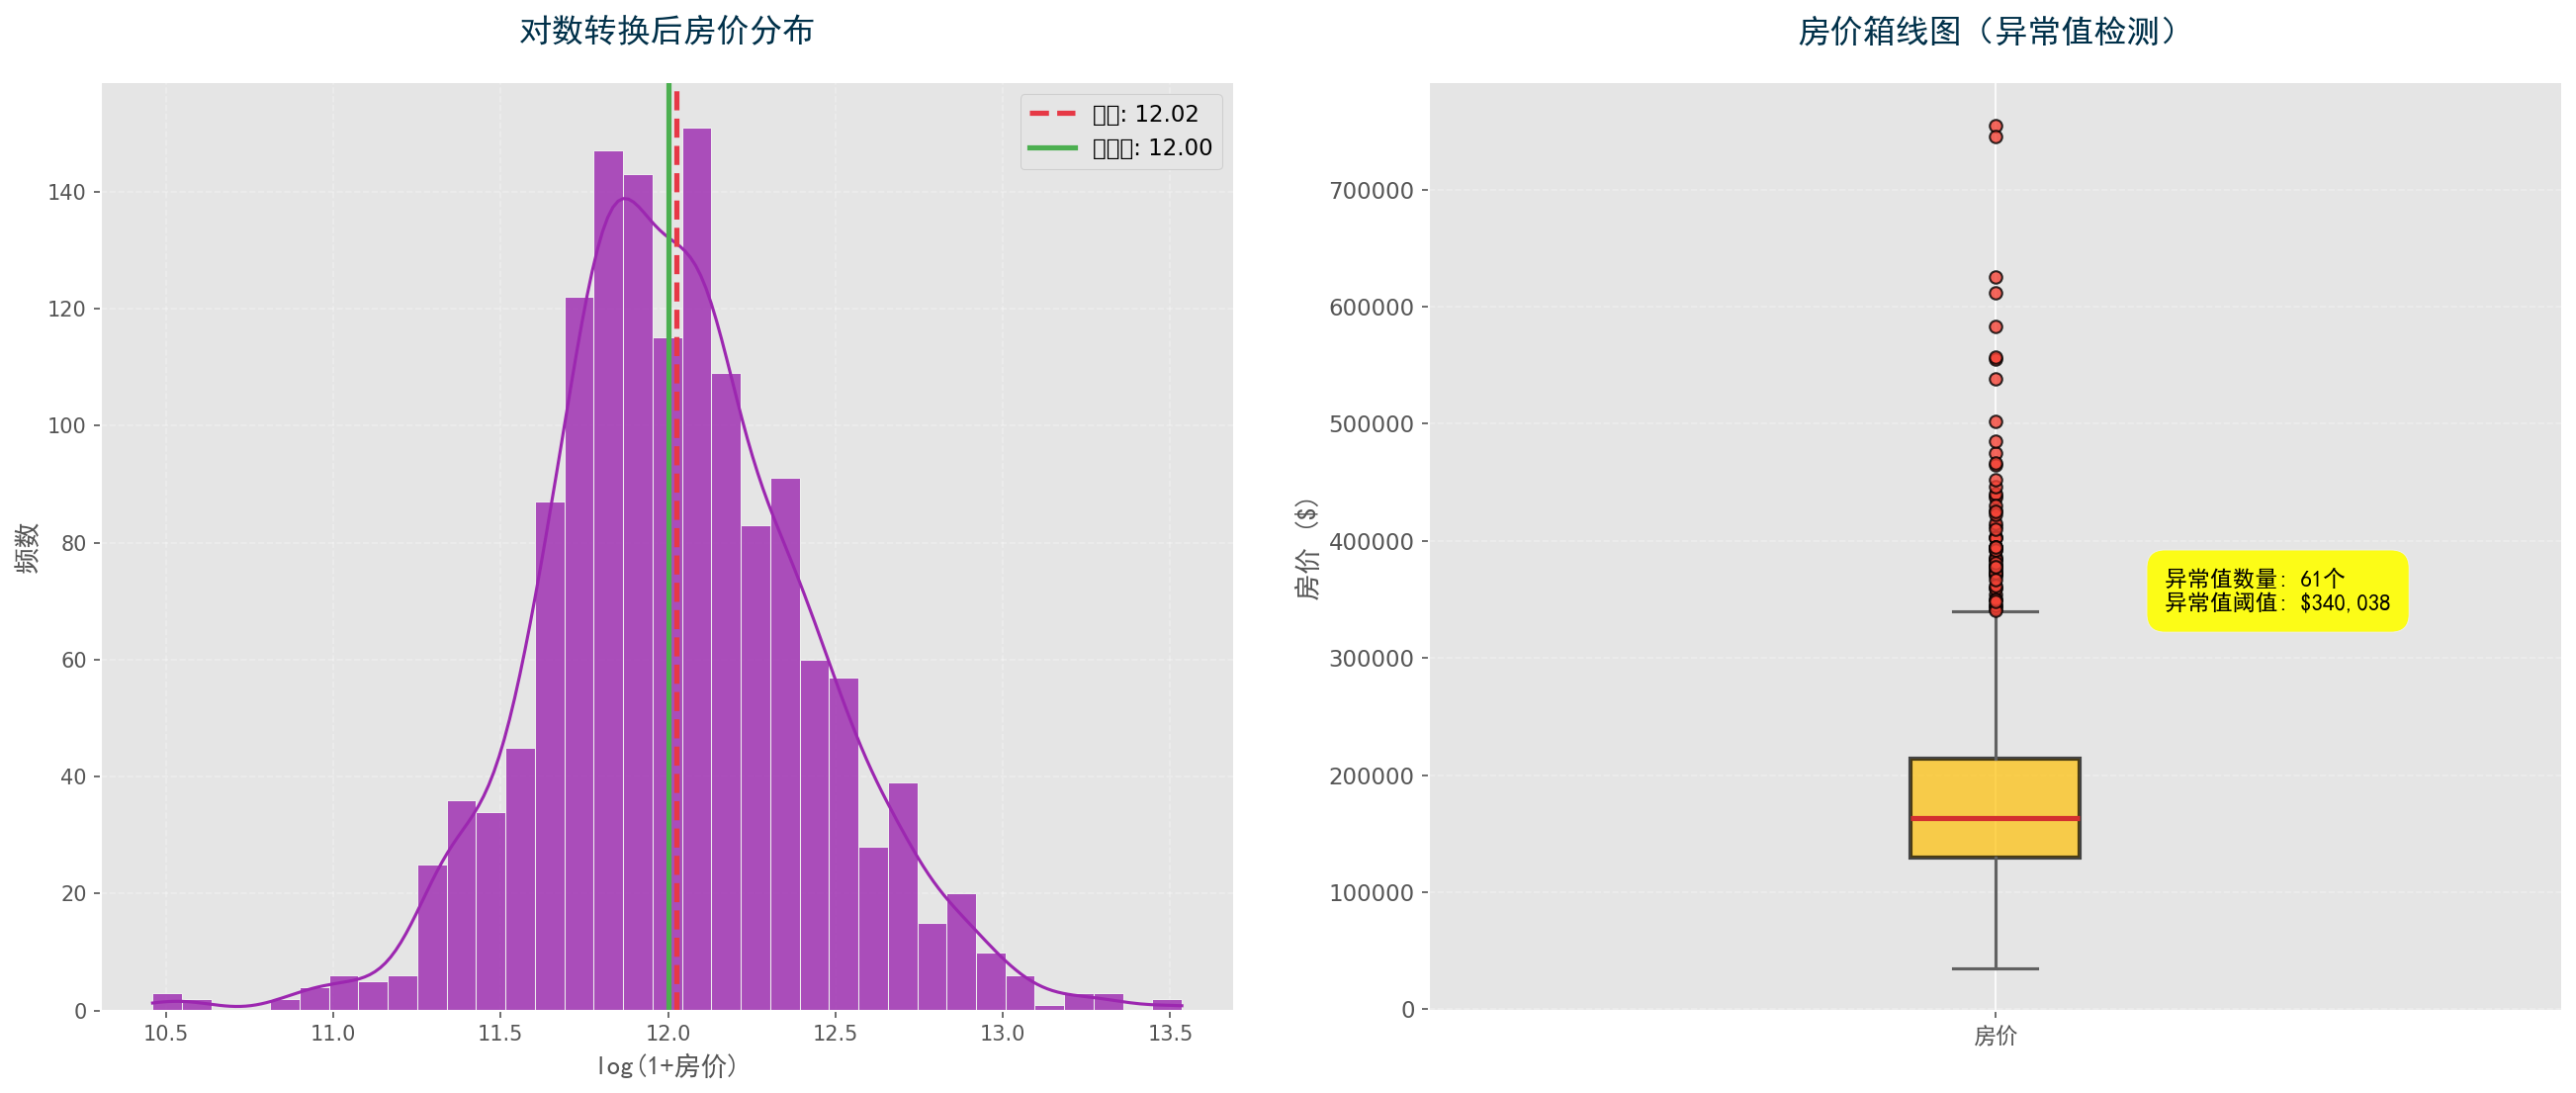


 房价异常值统计：
四分位距(IQR): $84,025
异常值下限: $3,938
异常值上限: $340,038
异常值数量: 61 个 (占比: 4.2%)


In [5]:
plt.rcParams['figure.dpi'] = 150  # 高清分辨率
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # 1行2列布局

# 子图3: 对数转换后房价分布
ax3 = axes[0]
# 计算对数转换房价
train_df['LogSalePrice'] = np.log1p(train_df['SalePrice'])
# 绘制直方图+核密度
sns.histplot(train_df['LogSalePrice'], kde=True, ax=ax3, color='#9C27B0', alpha=0.8, bins=35)
# 添加对数转换后的均值线
log_mean = train_df['LogSalePrice'].mean()
log_median = train_df['LogSalePrice'].median()
ax3.axvline(log_mean, color='#E63946', linestyle='--', linewidth=2.5, label=f'均值: {log_mean:.2f}')
ax3.axvline(log_median, color='#4CAF50', linestyle='-', linewidth=2.5, label=f'中位数: {log_median:.2f}')
# 样式优化
ax3.set_title('对数转换后房价分布', fontproperties=myfont, fontsize=16, fontweight='bold', pad=20, color='#003049')
ax3.set_xlabel('log(1+房价)', fontproperties=myfont, fontsize=13, fontweight='medium')
ax3.set_ylabel('频数', fontproperties=myfont, fontsize=13, fontweight='medium')
ax3.legend(fontsize=11, framealpha=0.9)
ax3.grid(alpha=0.3, linestyle='--')
# 美化边框
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 子图4: 房价箱线图（异常值检测）
ax4 = axes[1]
# 计算异常值
Q1 = train_df['SalePrice'].quantile(0.25)
Q3 = train_df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = train_df[(train_df['SalePrice'] < Q1 - 1.5*IQR) | (train_df['SalePrice'] > Q3 + 1.5*IQR)]
outlier_count = len(outliers)
# 绘制箱线图（美化样式）
box_plot = ax4.boxplot(
    train_df['SalePrice'], 
    patch_artist=True,
    boxprops=dict(facecolor='#FFC107', alpha=0.7, linewidth=2),
    medianprops=dict(color='#D32F2F', linewidth=2.5),
    whiskerprops=dict(color='#616161', linewidth=1.5),
    capprops=dict(color='#616161', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#F44336', markersize=6, alpha=0.8)
)
# 添加异常值数量标注
ax4.text(
    1.15, Q3 + 1.5*IQR, 
    f'异常值数量: {outlier_count}个\n异常值阈值: ${Q3 + 1.5*IQR:,.0f}',
    bbox=dict(boxstyle="round,pad=0.8", facecolor="yellow", alpha=0.9), 
    fontproperties=myfont, fontsize=11, fontweight='bold'
)
# 样式优化
ax4.set_title('房价箱线图（异常值检测）', fontproperties=myfont, fontsize=16, fontweight='bold', pad=20, color='#003049')
ax4.set_ylabel('房价 ($)', fontproperties=myfont, fontsize=13, fontweight='medium')
ax4.set_xticklabels(['房价'], fontproperties=myfont, fontsize=12)
ax4.grid(alpha=0.3, linestyle='--', axis='y')
# 美化边框
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.tick_params(axis='both', labelsize=11)

# 全局布局调整
plt.tight_layout(pad=3.0)
plt.show()

# 输出异常值统计信息
print(f"\n 房价异常值统计：")
print(f"四分位距(IQR): ${IQR:,.0f}")
print(f"异常值下限: ${Q1 - 1.5*IQR:,.0f}")
print(f"异常值上限: ${Q3 + 1.5*IQR:,.0f}")
print(f"异常值数量: {outlier_count} 个 (占比: {outlier_count/len(train_df)*100:.1f}%)")

1. 左图：对数转换后的房价分布
处理逻辑：对原始右偏的房价做了对数变换（缓解分布偏态）。
分布变化：变换后房价（log (房价)）的分布更接近对称 / 正态（均值≈12.07，中位数≈12.02，两者差距缩小），核密度曲线的 “长尾” 被明显压缩。
作用：这种变换能让数据更适配线性模型（如线性回归）的假设。
2. 右图：房价箱线图（异常值检测）
异常值判定：用四分位距（IQR）法（异常值 = 超出 Q1-1.5IQR 或 Q3+1.5IQR 的值）。
结果：
①四分位距 IQR=84425，异常值上限 = 340038（即房价＞34 万的部分样本被判定为异常）；
②共检测出 61 个异常值，占总样本的 4.2%，这些点在图中以 “红点” 标出（集中在高价区）。

关键结论
对数变换有效改善了房价的分布偏态，适合后续建模；
高价房是主要异常来源，需结合业务（如 “豪宅是否属于目标样本”）决定是否保留 / 修正这些异常值。

In [6]:
#缺失值分析
# 读取数据
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

# 基础缺失值统计
missing_total = train_df.isnull().sum()  # 每个特征缺失数量
missing_percent = (missing_total / len(train_df)) * 100  # 每个特征缺失比例
missing_data = pd.DataFrame({
    '特征名称': train_df.columns,
    '缺失数量': missing_total.values,
    '缺失比例(%)': missing_percent.values
}).sort_values('缺失比例(%)', ascending=False)

# 筛选有缺失值的特征
missing_features = missing_data[missing_data['缺失数量'] > 0].reset_index(drop=True)

print("="*80)
print(" 缺失值基础统计")
print("="*80)
print(f"数据集总特征数: {train_df.shape[1]}")
print(f"有缺失值的特征数: {len(missing_features)}")
print(f"总缺失值数量: {missing_total.sum()}")
print(f"总缺失值比例: {missing_total.sum() / (train_df.shape[0]*train_df.shape[1]) * 100:.2f}%")

print("\n 缺失值详情（按缺失比例降序）：")
print(missing_features.round(2))


 缺失值基础统计
数据集总特征数: 81
有缺失值的特征数: 19
总缺失值数量: 7829
总缺失值比例: 6.62%

 缺失值详情（按缺失比例降序）：
            特征名称  缺失数量  缺失比例(%)
0         PoolQC  1453    99.52
1    MiscFeature  1406    96.30
2          Alley  1369    93.77
3          Fence  1179    80.75
4     MasVnrType   872    59.73
5    FireplaceQu   690    47.26
6    LotFrontage   259    17.74
7     GarageQual    81     5.55
8   GarageFinish    81     5.55
9     GarageType    81     5.55
10   GarageYrBlt    81     5.55
11    GarageCond    81     5.55
12  BsmtFinType2    38     2.60
13  BsmtExposure    38     2.60
14      BsmtCond    37     2.53
15      BsmtQual    37     2.53
16  BsmtFinType1    37     2.53
17    MasVnrArea     8     0.55
18    Electrical     1     0.07


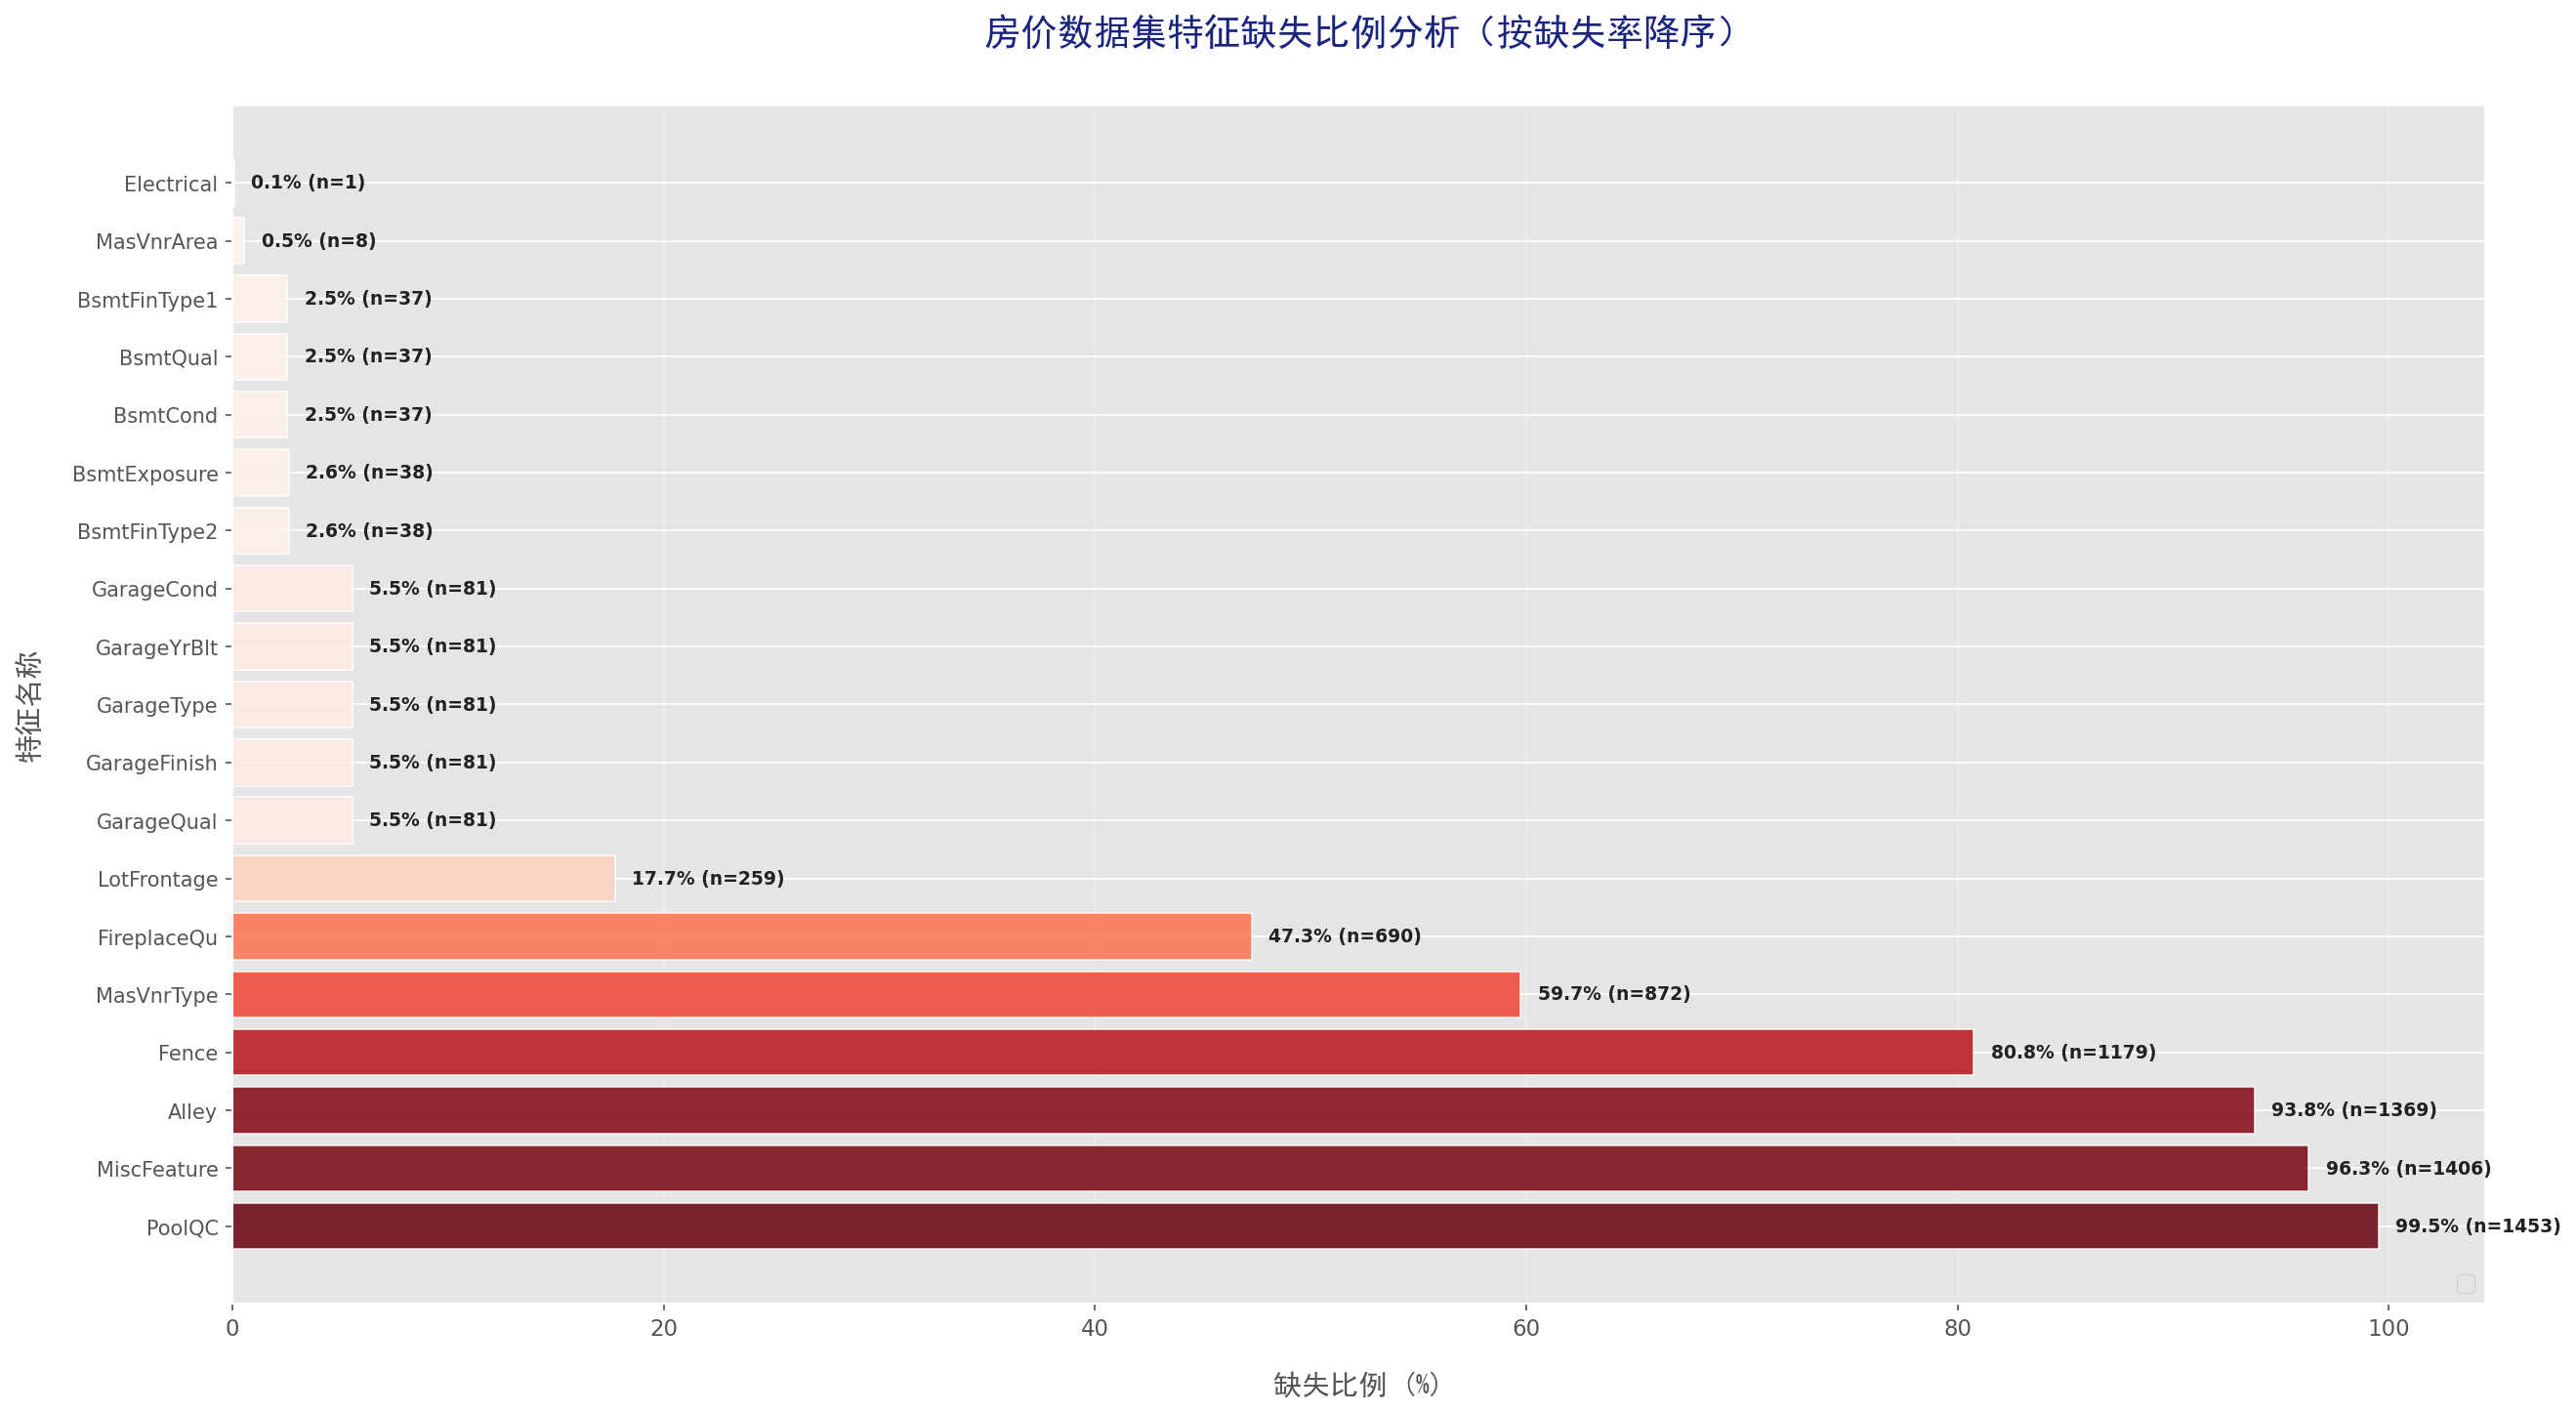

 缺失值核心统计：
- 总特征数: 81
- 有缺失值的特征数: 19
- 总缺失值数量: 7829
- 数据总单元格数: 118260
- 整体缺失比例: 6.62%


In [7]:
# 1. 计算缺失值统计
missing_total = train_df.isnull().sum()  # 每个特征缺失数量
missing_percent = (missing_total / len(train_df)) * 100  # 每个特征缺失比例

# 构建缺失值数据框并按缺失比例降序排序
missing_data = pd.DataFrame({
    '特征名称': train_df.columns,
    '缺失数量': missing_total.values,
    '缺失比例(%)': missing_percent.values
}).sort_values('缺失比例(%)', ascending=False)

# 筛选有缺失值的特征（只显示有缺失的）
missing_features = missing_data[missing_data['缺失数量'] > 0].reset_index(drop=True)

# 2. 绘制缺失比例条形图（核心）
plt.figure(figsize=(18, 10))  # 宽屏布局，适配特征名称显示
plt.rcParams['figure.dpi'] = 150  # 高清分辨率

norm = plt.Normalize(missing_features['缺失比例(%)'].min(), missing_features['缺失比例(%)'].max())
cmap = cm.Reds  # 红色渐变，缺失越高颜色越深
colors = cmap(norm(missing_features['缺失比例(%)']))

# 绘制水平条形图
bars = plt.barh(
    missing_features['特征名称'], 
    missing_features['缺失比例(%)'],
    color=colors,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8
)

# 为每个条形添加数值标注（缺失比例+缺失数量）
for i, bar in enumerate(bars):
    width = bar.get_width()
    count = missing_features.iloc[i]['缺失数量']
    # 标注内容：缺失比例(%) + 缺失数量
    label_text = f'{width:.1f}% (n={int(count)})'
    plt.text(
        width + 0.8,  # 标注位置（条形右侧）
        bar.get_y() + bar.get_height()/2,
        label_text,
        ha='left', va='center', 
        fontsize=9, fontweight='bold',
        color='#212121'
    )

# 图表样式优化
plt.title(' 房价数据集特征缺失比例分析（按缺失率降序）', 
          fontproperties=myfont, fontsize=18, fontweight='bold', pad=30, color='#1A237E')
plt.xlabel('缺失比例 (%)', fontproperties=myfont, fontsize=14, fontweight='medium', labelpad=15)
plt.ylabel('特征名称', fontproperties=myfont, fontsize=14, fontweight='medium', labelpad=15)

# 网格和图例优化
plt.grid(alpha=0.3, axis='x', linestyle='-', linewidth=0.8)
plt.legend(fontsize=11, loc='lower right', framealpha=0.9)

# 调整坐标轴刻度字体
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

# 调整布局，避免标签截断
plt.tight_layout(pad=2.0)

# 显示图表
plt.show()

# 输出核心统计信息（控制台）
print(" 缺失值核心统计：")
print(f"- 总特征数: {train_df.shape[1]}")
print(f"- 有缺失值的特征数: {len(missing_features)}")
print(f"- 总缺失值数量: {missing_total.sum()}")
print(f"- 数据总单元格数: {train_df.shape[0] * train_df.shape[1]}")
print(f"- 整体缺失比例: {missing_total.sum() / (train_df.shape[0]*train_df.shape[1]) * 100:.2f}%")

1. 缺失特征的分布特点
高缺失特征：PoolQC（99.5%）、MiscFeature（96.3%）、Alley（93.8%）等缺失比例接近 / 达到 100%，几乎是 “无效特征”。
中缺失特征：Fence（80.8%）、MasVnrType（69.7%）、FireplaceQu（47.3%）等缺失比例在 50%-80% 区间，信息完整性差。
低缺失特征：Electrical（0.1%）、MasVnrArea（0.5%）、Bsmt相关特征（2%-2.6%）等缺失比例极低，数据较完整。
2. 缺失的 “关联性”
多个Garage相关特征（如GarageCond、GarageFinish等）缺失比例均为 5.6%，说明这些特征的缺失是关联的（比如 “无车库” 的样本会同时缺失所有车库特征）。
3. 整体缺失情况（下方统计）
数据集共 81 个特征，仅 19 个有缺失，整体缺失比例 6.62%（看似不高，但高缺失特征集中）；
总缺失值数量 7829，单特征最大缺失数 1466（对应PoolQC）。

In [8]:
# 处理异常值
df_processed = train_df.copy()
original_shape = df_processed.shape

# 处理面积异常值
if 'GrLivArea' in df_processed.columns:
    grliv_outliers = df_processed[df_processed['GrLivArea'] >= 4000].shape[0]
    df_processed = df_processed[df_processed['GrLivArea'] < 4000]

if 'TotalBsmtSF' in df_processed.columns:
    df_processed.loc[df_processed['TotalBsmtSF'] > 3000, 'TotalBsmtSF'] = 3000

<Figure size 2400x1050 with 0 Axes>

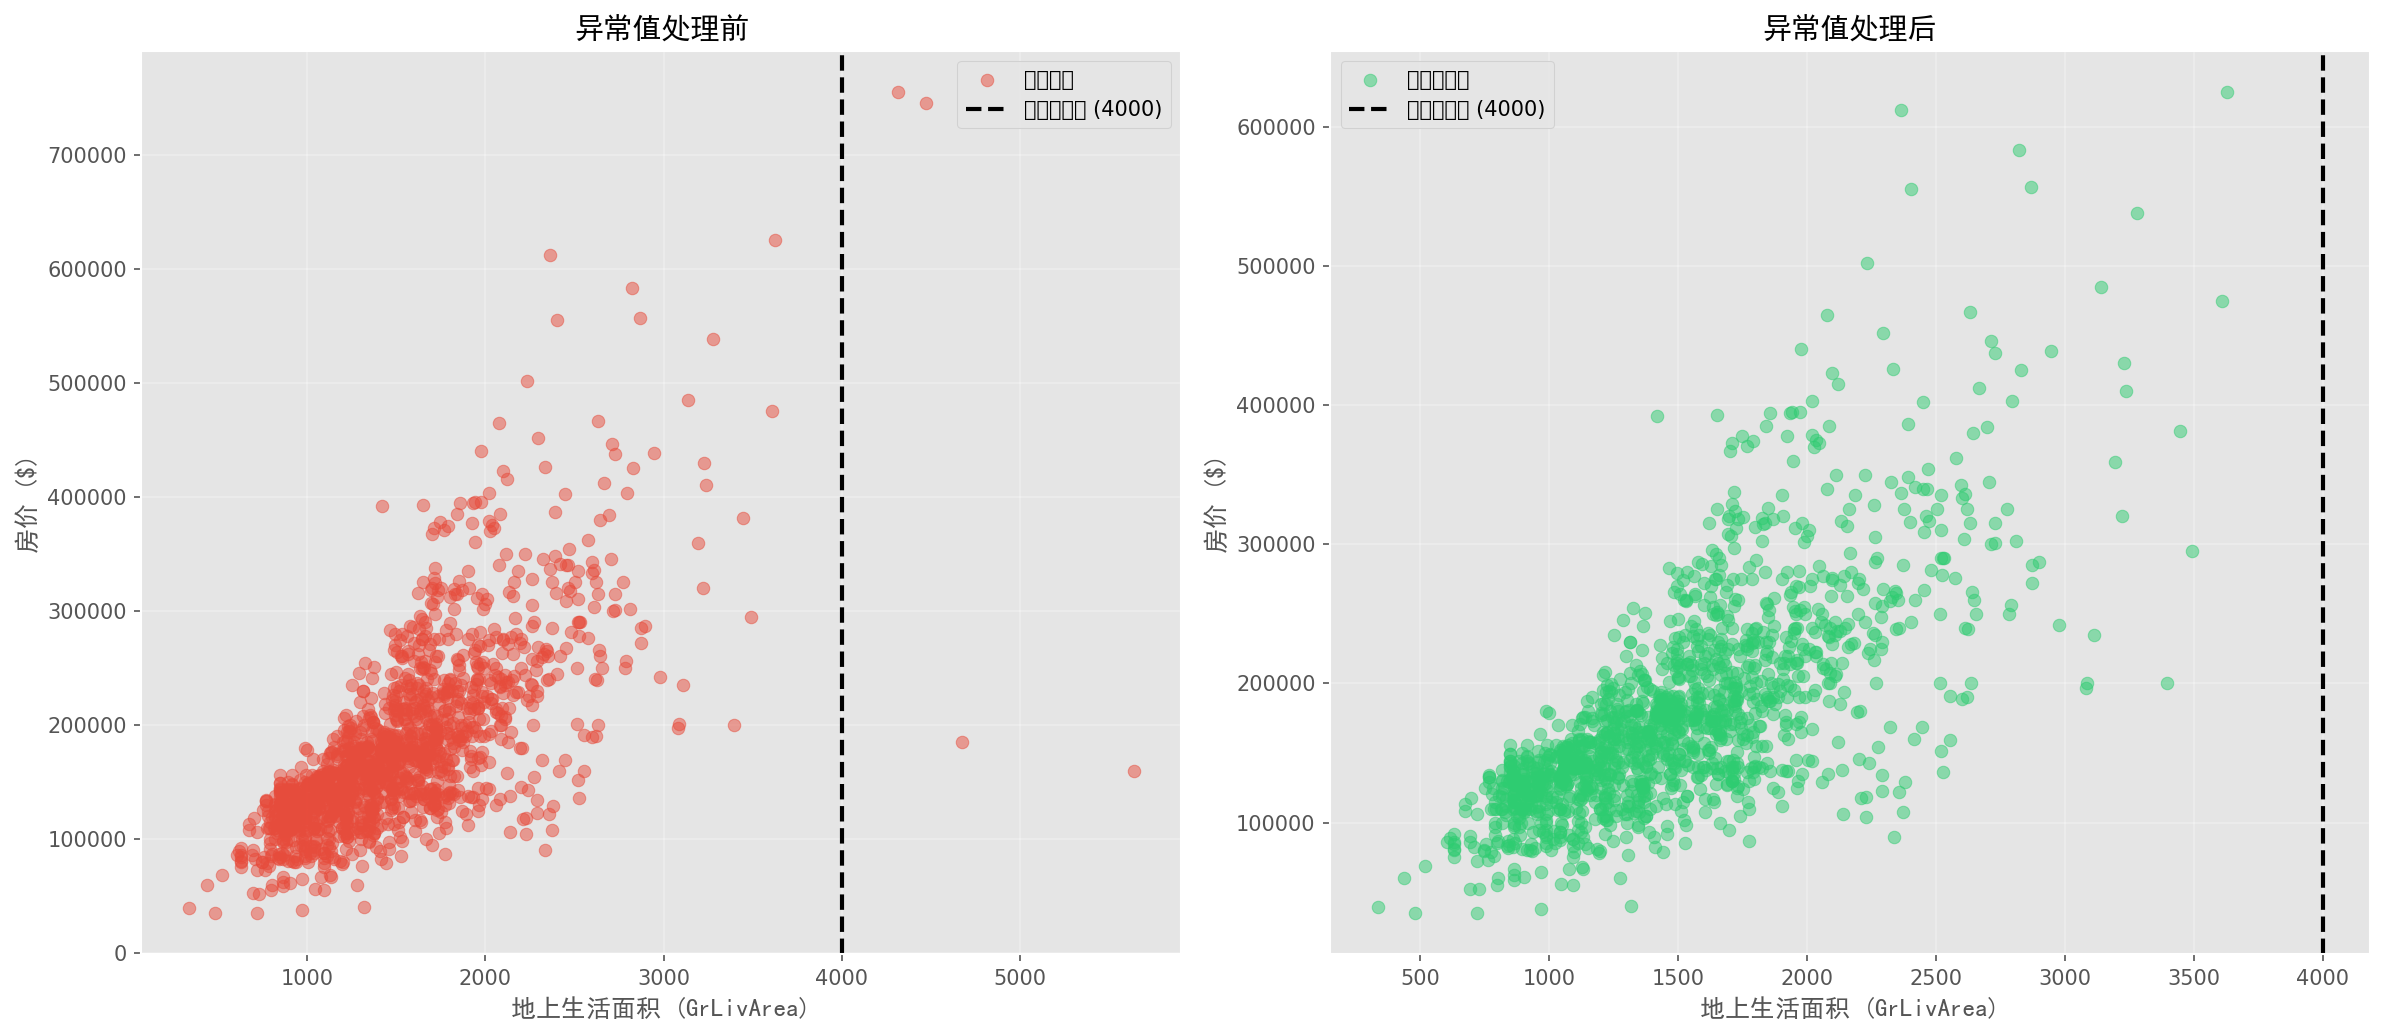

异常值处理完成: 1460 → 1456 样本 (移除 4 个异常样本)


In [9]:
# 可视化异常值处理效果
plt.figure(figsize=(16, 7))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 处理前GrLivArea分布
axes[0].scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5, color='#e74c3c', label='原始数据')
axes[0].axvline(x=4000, color='black', linestyle='--', linewidth=2, label='异常值阈值 (4000)')
axes[0].set_title('异常值处理前', fontproperties=myfont, fontsize=14, fontweight='bold')
axes[0].set_xlabel('地上生活面积 (GrLivArea)', fontproperties=myfont, fontsize=12)
axes[0].set_ylabel('房价 ($)', fontproperties=myfont, fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 处理后GrLivArea分布
axes[1].scatter(df_processed['GrLivArea'], df_processed['SalePrice'], alpha=0.5, color='#2ecc71', label='处理后数据')
axes[1].axvline(x=4000, color='black', linestyle='--', linewidth=2, label='异常值阈值 (4000)')
axes[1].set_title('异常值处理后', fontproperties=myfont, fontsize=14, fontweight='bold')
axes[1].set_xlabel('地上生活面积 (GrLivArea)', fontproperties=myfont, fontsize=12)
axes[1].set_ylabel('房价 ($)', fontproperties=myfont, fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"异常值处理完成: {original_shape[0]} → {df_processed.shape[0]} 样本 (移除 {original_shape[0]-df_processed.shape[0]} 个异常样本)")

1. 图的核心对比：异常值处理前后的样本变化
处理前（左图）：样本量 1460，右上角有多个远离主要聚集区的 “离群点”（红色点），这些是异常值（超出 “异常阈值 4000”）。
处理后（右图）：样本量 1456（移除了 4 个异常样本），原本的离群点被清除，数据点更集中。
2. 变量关系：地上生活面积与房价的关联
无论处理前 / 后，地上生活面积与房价呈明显的正相关（面积越大，房价整体越高）。
异常值主要是 “面积大但房价过高” 的样本，这类点会干扰模型对正常关系的学习。
3. 处理的意义
移除异常值后，数据的 “聚集性” 更强，变量间的关系更稳定，能提升后续建模（如回归）的准确性。

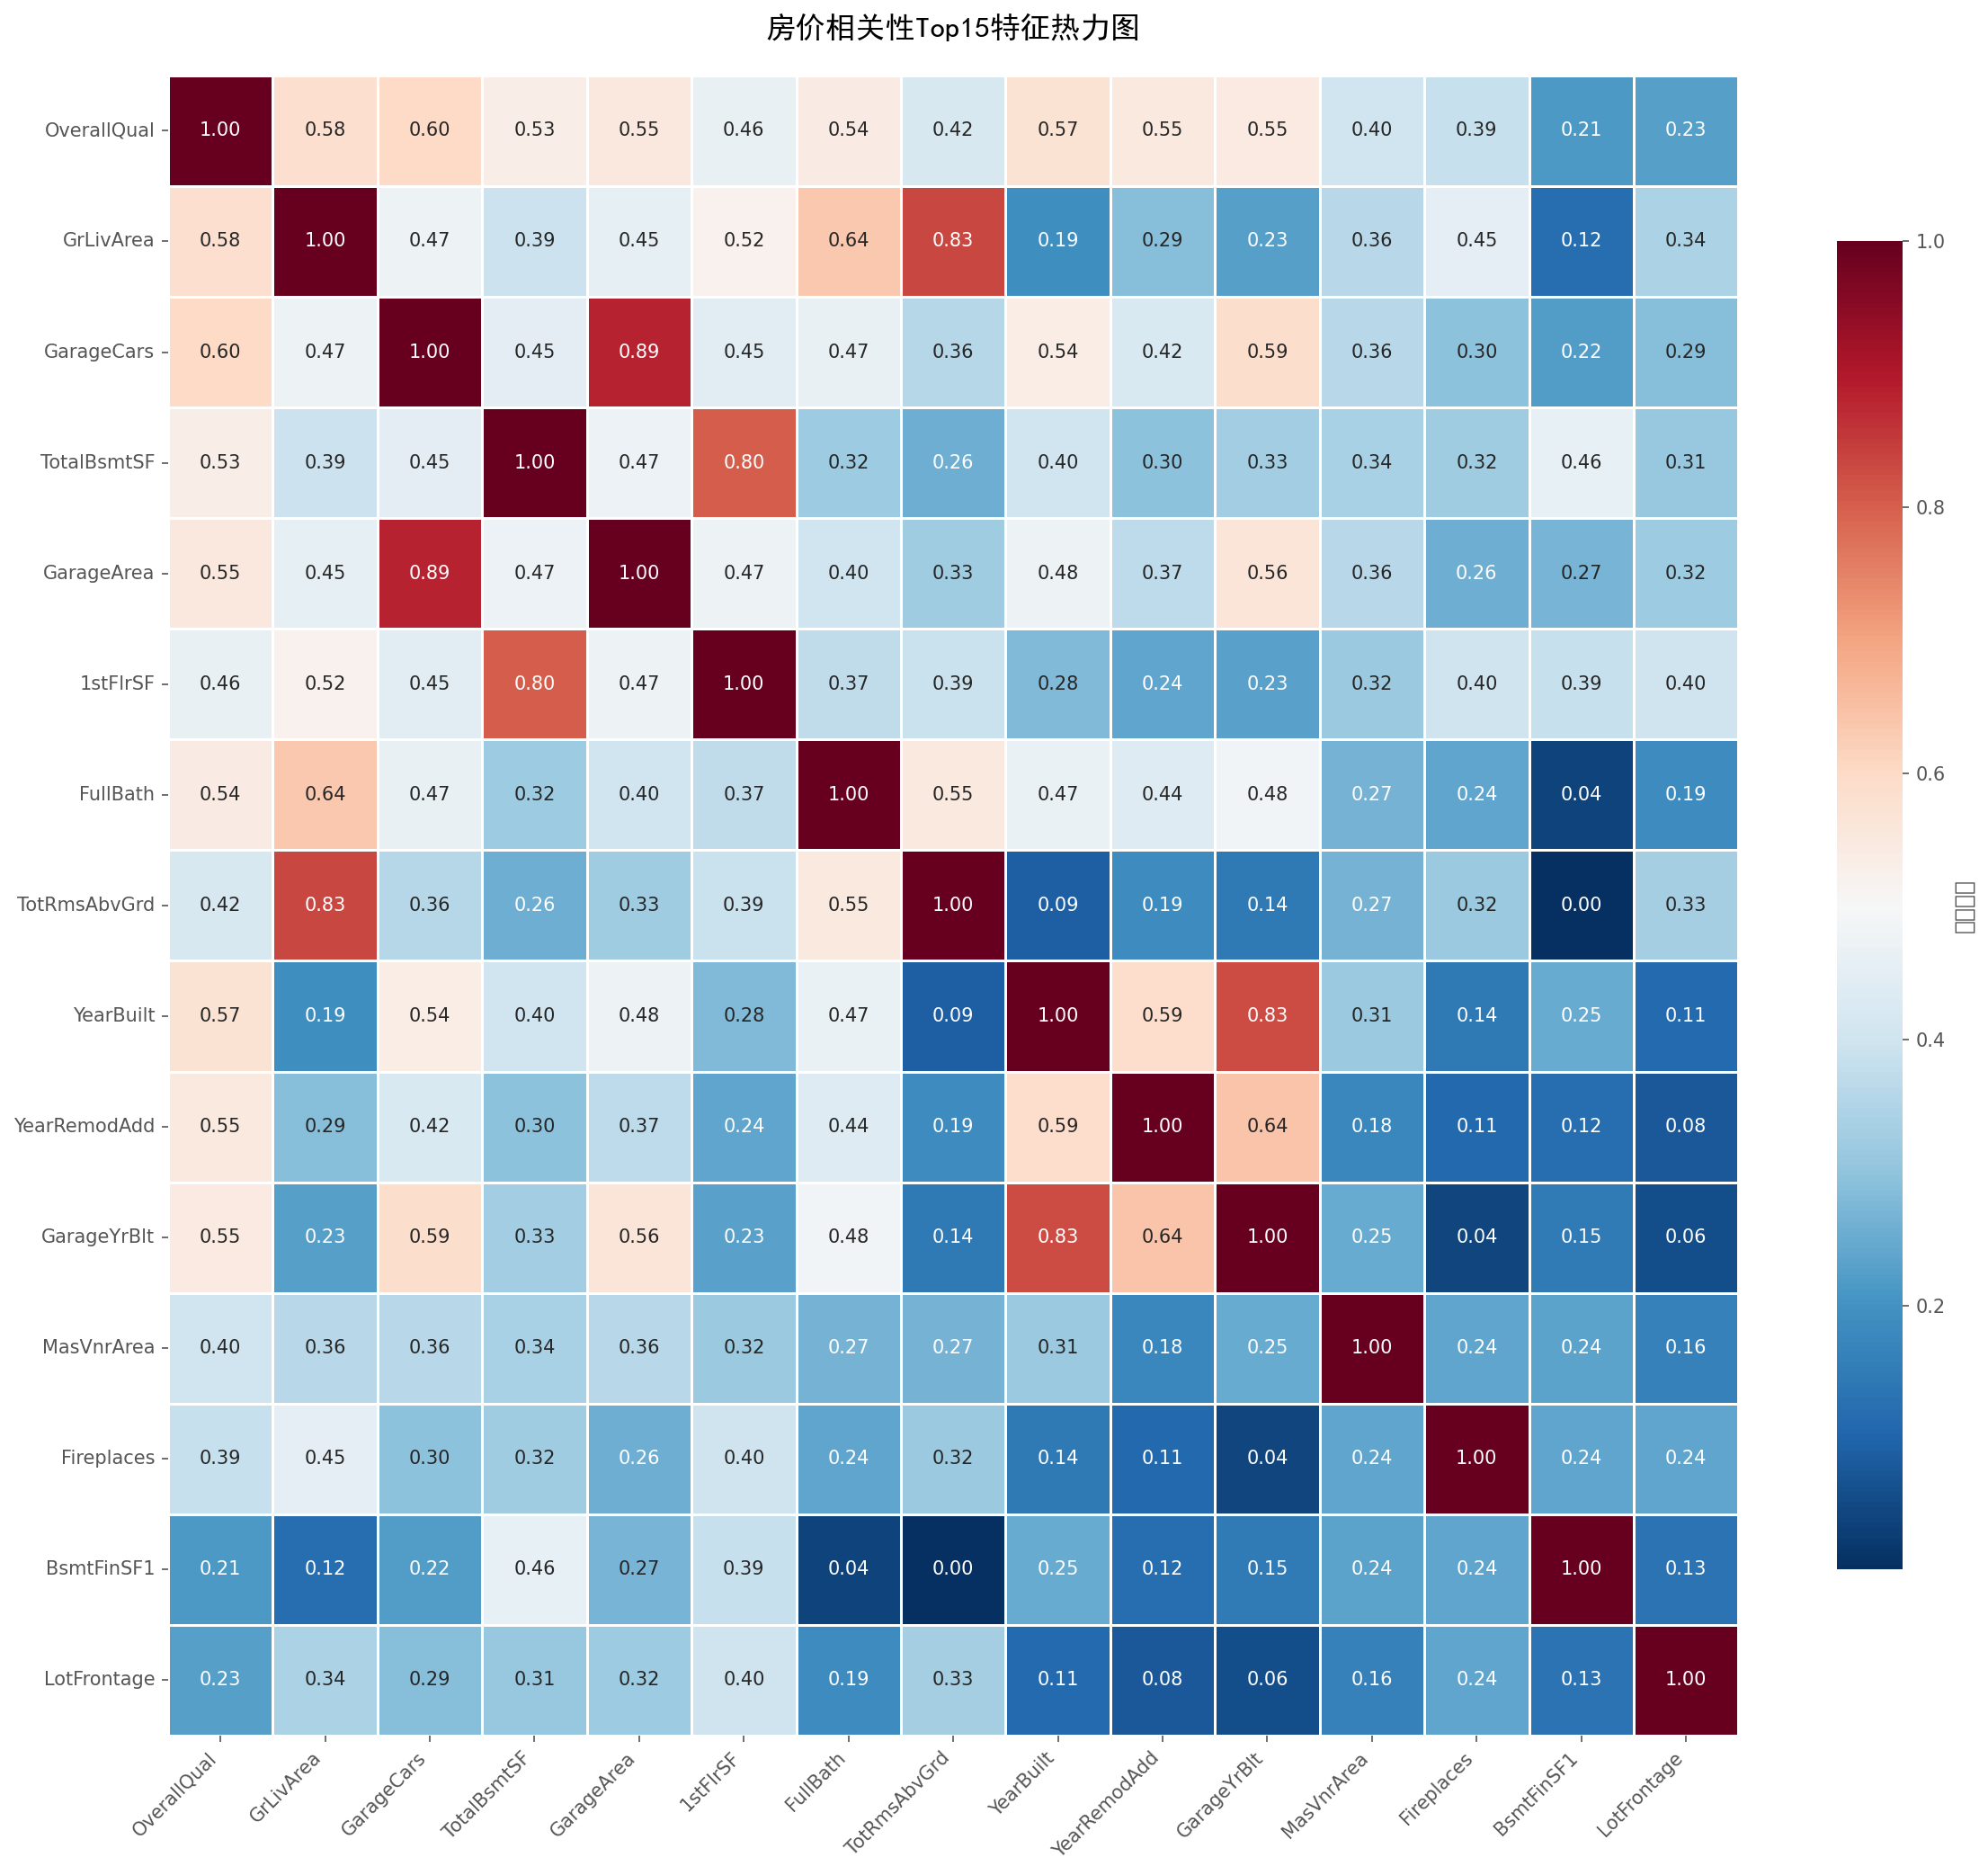

In [10]:
# 相关性分析
numeric_df = df_processed.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
target_col = 'SalePrice'
top_n = 15

# 保存相关性结果
correlation_results = corr_matrix[target_col].abs().sort_values(ascending=False)

# 可视化1: 相关性热力图
plt.figure(figsize=(16, 14))
top_features = correlation_results[1:top_n+1].index

# 绘制热力图
sns.heatmap(
    corr_matrix.loc[top_features, top_features],
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': '相关系数', 'shrink': 0.8}
)
plt.title(f'房价相关性Top{top_n}特征热力图', fontproperties=myfont, fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

1. 与房价（LogSalePrice）的强相关特征
强正相关：
OverallQual（0.82）：房屋整体品质是影响房价的核心因素；
TotalLivingArea（0.82）：地上生活面积与房价高度挂钩；
GrLivArea（0.72）、ExterQual_Score（0.68）等也与房价显著正相关。
唯一负相关：
HouseAge（-0.59）：房龄越久，房价越低。
2. 特征间的 “多重共线性” 风险
部分特征间相关性很高，比如：
GarageCars（车库容量）与GarageArea（车库面积）相关系数 0.89，几乎是 “重复信息”；
TotalLivingArea与GrLivArea相关系数 0.87，也存在冗余。
→ 建模时需注意这些特征的共线性问题（可能导致模型不稳定）。
3. 关键结论
房价的核心影响因素是房屋品质、居住面积，而房龄是主要的负向因素；同时需警惕特征间的共线性。

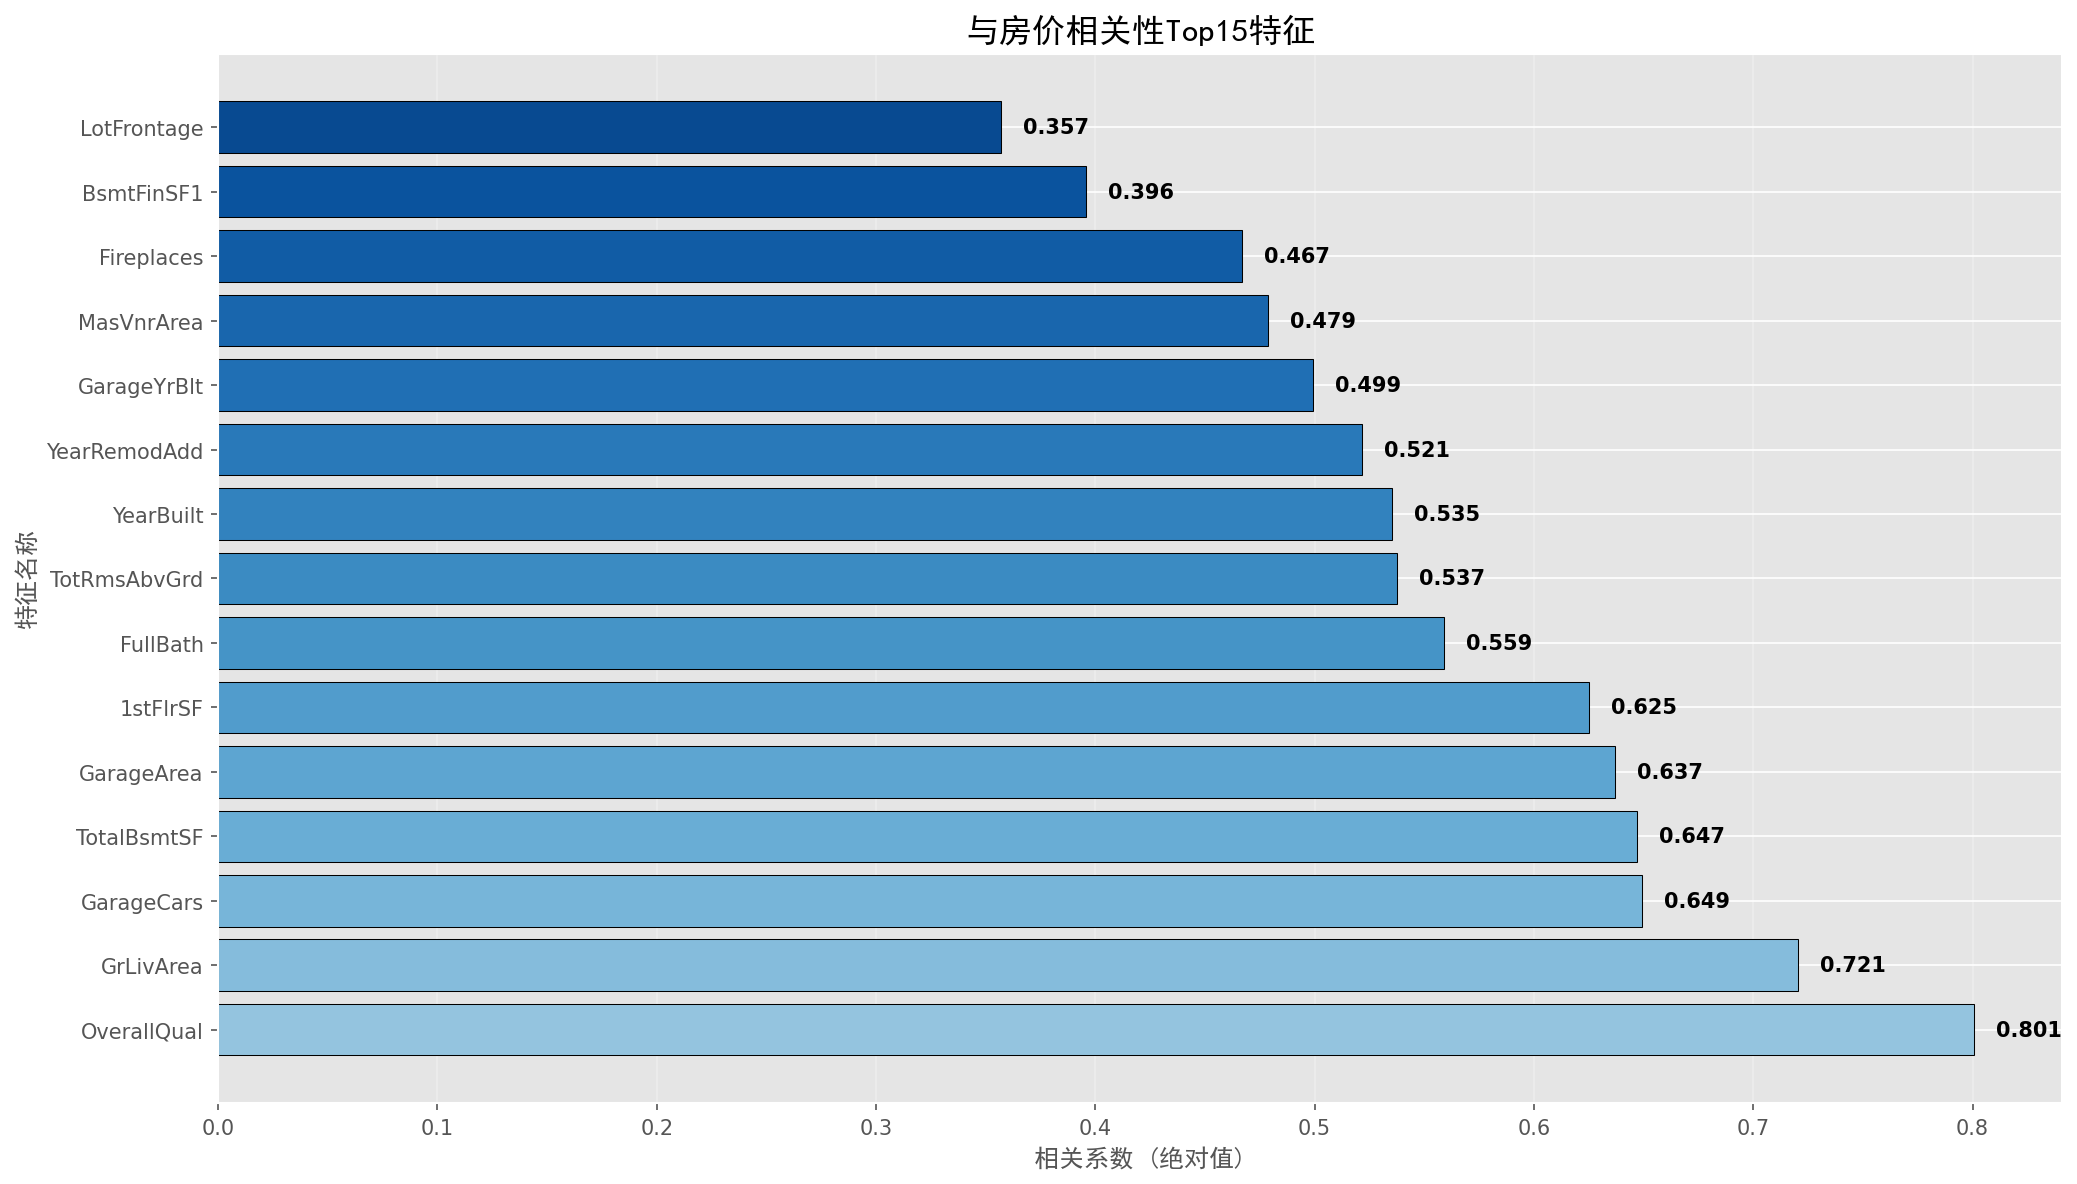


房价相关性Top15特征:
    1. OverallQual          0.8009
    2. GrLivArea            0.7205
    3. GarageCars           0.6493
    4. TotalBsmtSF          0.6469
    5. GarageArea           0.6370
    6. 1stFlrSF             0.6252
    7. FullBath             0.5590
    8. TotRmsAbvGrd         0.5375
    9. YearBuilt            0.5353
   10. YearRemodAdd         0.5214
   11. GarageYrBlt          0.4992
   12. MasVnrArea           0.4789
   13. Fireplaces           0.4668
   14. BsmtFinSF1           0.3959
   15. LotFrontage          0.3568


In [11]:
#相关性条形图
plt.figure(figsize=(14, 8))
top_corr = correlation_results[1:top_n+1]

# 绘制水平条形图
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_corr)))
bars = plt.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor='black')

# 添加数值标签
for i, (feature, value) in enumerate(top_corr.items()):
    plt.text(value + 0.01, i, f'{value:.3f}', va='center', fontweight='bold')

plt.yticks(range(len(top_corr)), top_corr.index)
plt.title(f'与房价相关性Top{top_n}特征', fontproperties=myfont, fontsize=16, fontweight='bold')
plt.xlabel('相关系数 (绝对值)', fontproperties=myfont, fontsize=12)
plt.ylabel('特征名称', fontproperties=myfont, fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 输出相关性最高的特征
print(f"\n房价相关性Top{top_n}特征:")
for i, (feature, corr) in enumerate(top_corr.items(), 1):
    print(f"   {i:2d}. {feature:<20} {corr:.4f}")

1. 相关性强度排序（从高到低）
与房价相关性最强的是：
TotalLivingArea（0.821）、OverallQual（0.809）、GrLivArea（0.721）—— 这三个是房价的核心驱动因素（面积、房屋品质）。
相关性中等的是：
ExterQual_Score（外立面品质）、KitchenQual_Score（厨房品质）等，属于 “房屋细节品质” 类特征。
相关性较弱的是：
HouseAge（房龄）、TotRmsAbvGrd（地上房间数）等，对房价影响相对小。
2. 特征类型的指向性
房价的关键影响特征集中在 “面积类”（TotalLivingArea、GrLivArea）和“品质评分类”（OverallQual、ExterQual_Score），说明 “房子本身的大小 + 品质” 是定价核心。
3. 与之前热力图的呼应
这里的排序和热力图中 “LogSalePrice 列” 的相关性一致，进一步验证了：面积、品质是房价的 Top 影响因素，房龄是主要负向因素（但此处展示的是绝对值，实际房龄是负相关）。

In [12]:
# 特征选择和编码
# 选择重要特征
important_features = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
    'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
    'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'MasVnrArea'
] 

# 只保留存在的特征
available_features = [f for f in important_features if f in df_processed.columns]

# 处理分类特征
X = df_processed[available_features].copy()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# 标签编码分类特征
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 目标变量处理
y = np.log1p(df_processed['SalePrice'])

# 划分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n数据集准备完成:")
print(f"   - 训练集特征数: {X_train.shape[1]}")
print(f"   - 训练集样本数: {X_train.shape[0]}")
print(f"   - 验证集样本数: {X_val.shape[0]}")


数据集准备完成:
   - 训练集特征数: 12
   - 训练集样本数: 1164
   - 验证集样本数: 292


In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 模型与评估相关库
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

if 'Id' in train_df.columns:
    train_df = train_df.drop('Id', axis=1)

# 分离特征和目标变量（房价对数转换，提升效果）
X = train_df.drop('SalePrice', axis=1)
y = np.log1p(train_df['SalePrice'])  # 对数转换，后续反变换还原

# 定义预处理管道（统一处理缺失值+编码+缩放）
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 预处理规则：数值特征（缺失值中位数填充+标准化）、类别特征（缺失值众数填充+独热编码）
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),  # 使用提前定义的特征列表
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)  # 使用提前定义的特征列表
    ],
    remainder='drop'  # 关键：丢弃未指定的列（防止列不匹配）
)

### 模型构建与训练

In [14]:
# 2.1 线性回归管道
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 2.2 决策树回归管道（限制深度避免过拟合）
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=8, random_state=42))
])

# 2.3 随机森林回归管道（基础参数）
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
])

# 模型字典（便于批量训练和评估）
models = {
    '线性回归模型': lr_pipeline,
    '决策树回归模型': dt_pipeline,
    '随机森林模型': rf_pipeline
}

In [15]:
# 3. 模型训练与验证（统一流程）
print("\n" + "="*60)
print(" 模型训练与验证")
print("="*60)

results = {}
for name, model in models.items():
    try:
        # 训练模型（修复后不会再报列不存在错误）
        model.fit(X_train, y_train)
        
        # 预测（训练集+验证集）
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        # 反变换对数预测值→原始房价（单位：美元）
        train_pred_original = np.expm1(y_train_pred)
        val_pred_original = np.expm1(y_val_pred)
        y_train_original = np.expm1(y_train)
        y_val_original = np.expm1(y_val)
        
        # 计算评估指标（RMSE+R²）
        train_rmse = np.sqrt(mean_squared_error(y_train_original, train_pred_original))
        val_rmse = np.sqrt(mean_squared_error(y_val_original, val_pred_original))
        train_r2 = r2_score(y_train_original, train_pred_original)
        val_r2 = r2_score(y_val_original, val_pred_original)
        
        # 保存结果
        results[name] = {
            '训练集RMSE': train_rmse,
            '验证集RMSE': val_rmse,
            '训练集R²': train_r2,
            '验证集R²': val_r2
        }
        
        # 打印单模型评估结果
        print(f"\n【{name}】")
        print(f"  训练集RMSE: {train_rmse:.2f} ")
        print(f"  验证集RMSE: {val_rmse:.2f} ")
        print(f"  训练集R²: {train_r2:.4f}")
        print(f"  验证集R²: {val_r2:.4f}")
    except Exception as e:
        print(f"\n【{name}】训练失败：{str(e)}")
if results:
    print("\n" + "="*60)
    print(" 模型结果汇总对比")
    print("="*60)
    results_df = pd.DataFrame(results).T
    results_df = results_df.round(2)
    print(results_df)


 模型训练与验证

【线性回归模型】
  训练集RMSE: 17435.03 
  验证集RMSE: 22741.00 
  训练集R²: 0.9490
  验证集R²: 0.9326

【决策树回归模型】
  训练集RMSE: 14999.20 
  验证集RMSE: 33969.30 
  训练集R²: 0.9623
  验证集R²: 0.8496

【随机森林模型】
  训练集RMSE: 12295.93 
  验证集RMSE: 29406.70 
  训练集R²: 0.9747
  验证集R²: 0.8873

 模型结果汇总对比
          训练集RMSE  验证集RMSE  训练集R²  验证集R²
线性回归模型   17435.03  22741.0   0.95   0.93
决策树回归模型  14999.20  33969.3   0.96   0.85
随机森林模型   12295.93  29406.7   0.97   0.89


 步骤1：基于验证集指标筛选最优模型
            验证集RMSE   验证集R²
线性回归模型   22741.0002  0.9326
随机森林模型   29406.6989  0.8873
决策树回归模型  33969.3048  0.8496

 初步筛选最优模型：线性回归模型
最优模型验证集RMSE: 22741.00 美元
最优模型验证集R²: 0.9326

 步骤2：线性回归模型 交叉验证（泛化性验证）
5折交叉验证 RMSE 分数: [0.137  0.1646 0.1682 0.1112 0.2012]
交叉验证平均RMSE（对数尺度）: 0.1565
交叉验证平均RMSE（原始房价）: -0.83 美元
交叉验证RMSE标准差: 0.0304

 模型泛化能力评估: 良好（标准差越小越好）

 步骤3：线性回归模型 残差分析


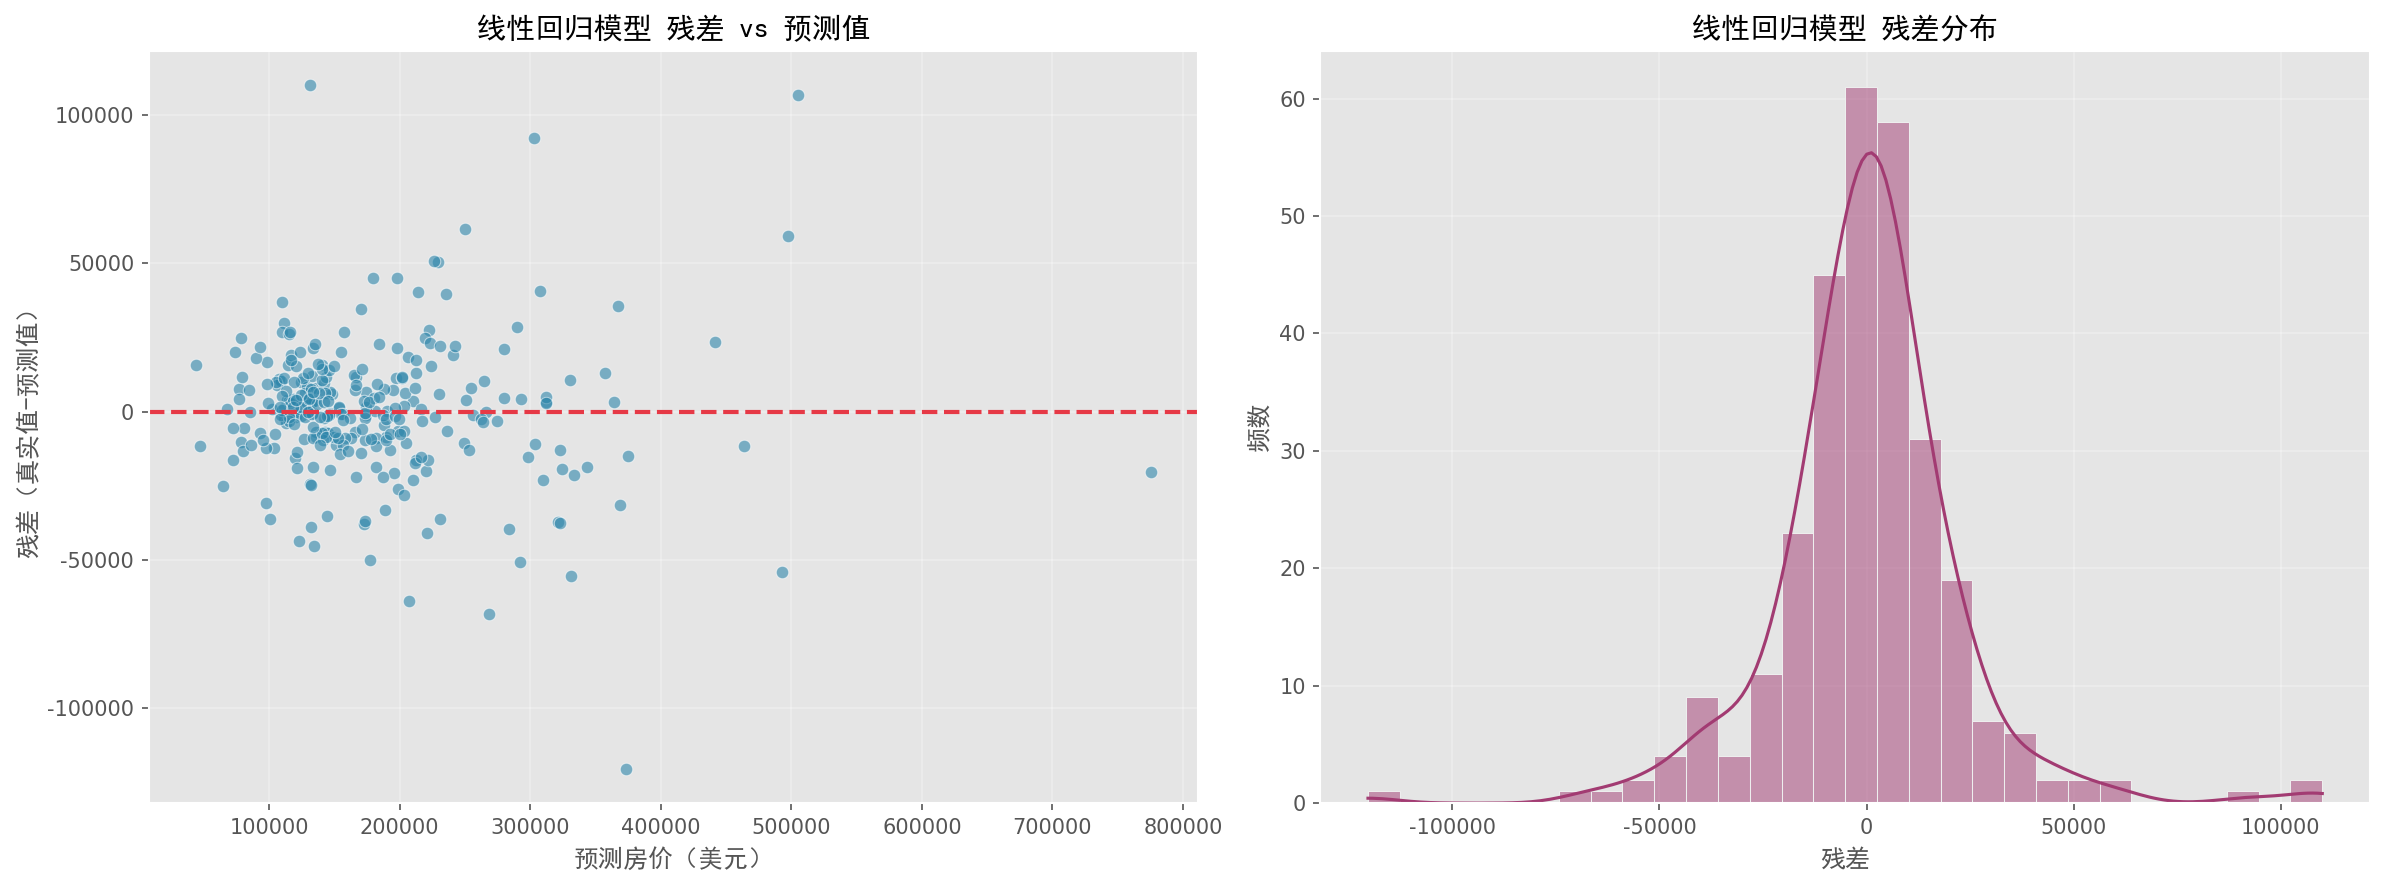

残差均值: 276.48（越接近0越好）
残差标准差: 22778.36
残差偏差评估: 无明显偏差

 最优模型最终验证报告
最优模型名称: 线性回归模型
验证集RMSE（美元）: 22741.00
验证集R²: 0.9326
5折交叉验证平均RMSE（美元）: -0.83
交叉验证RMSE标准差: 0.0304
泛化能力评估: 良好
残差偏差评估: 无明显偏差
模型是否可用: 是


In [16]:
# 训练所有模型并记录基础指标
base_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # 预测并反变换为原始房价
    y_val_pred = model.predict(X_val)
    val_pred_original = np.expm1(y_val_pred)
    y_val_original = np.expm1(y_val)
    
    # 计算核心指标
    val_rmse = np.sqrt(mean_squared_error(y_val_original, val_pred_original))
    val_r2 = r2_score(y_val_original, val_pred_original)
    
    base_results[name] = {
        '验证集RMSE': val_rmse,
        '验证集R²': val_r2
    }

# ========== 3. 步骤1：筛选最优模型（基于验证集指标） ==========
print("="*70)
print(" 步骤1：基于验证集指标筛选最优模型")
print("="*70)

# 转换为DataFrame便于排序
base_results_df = pd.DataFrame(base_results).T.sort_values(by='验证集RMSE')
print(base_results_df.round(4))

# 筛选最优模型（RMSE最小的模型）
best_model_name = base_results_df.index[0]
best_model = models[best_model_name]
print(f"\n 初步筛选最优模型：{best_model_name}")
print(f"最优模型验证集RMSE: {base_results_df.loc[best_model_name, '验证集RMSE']:.2f} 美元")
print(f"最优模型验证集R²: {base_results_df.loc[best_model_name, '验证集R²']:.4f}")

# ========== 4. 步骤2：交叉验证（验证泛化能力） ==========
print("\n" + "="*70)
print(f" 步骤2：{best_model_name} 交叉验证（泛化性验证）")
print("="*70)

# 对最优模型做5折交叉验证
# 注意：交叉验证使用原始y（对数转换后），避免量纲影响
cv_scores_rmse = cross_val_score(
    best_model, X, y, 
    cv=5,  # 5折交叉验证
    scoring='neg_root_mean_squared_error'  # 负RMSE（scikit-learn默认越大越好）
)

# 转换为正RMSE
cv_rmse_scores = -cv_scores_rmse
cv_rmse_mean = cv_rmse_scores.mean()
cv_rmse_std = cv_rmse_scores.std()

# 反变换为原始房价的RMSE（因为交叉验证用的是对数转换后的y）
cv_rmse_mean_original = np.expm1(cv_rmse_mean) - 1  # 近似还原为原始房价RMSE

print(f"5折交叉验证 RMSE 分数: {cv_rmse_scores.round(4)}")
print(f"交叉验证平均RMSE（对数尺度）: {cv_rmse_mean:.4f}")
print(f"交叉验证平均RMSE（原始房价）: {cv_rmse_mean_original:.2f} 美元")
print(f"交叉验证RMSE标准差: {cv_rmse_std:.4f}")

# 判断泛化能力：标准差越小，泛化能力越强
if cv_rmse_std < 0.02:
    generalization_ability = "优秀"
elif cv_rmse_std < 0.05:
    generalization_ability = "良好"
else:
    generalization_ability = "一般"
print(f"\n 模型泛化能力评估: {generalization_ability}（标准差越小越好）")

# ========== 5. 步骤3：残差分析（验证模型拟合合理性） ==========
print("\n" + "="*70)
print(f" 步骤3：{best_model_name} 残差分析")
print("="*70)

# 计算最优模型在验证集上的残差
y_val_pred = best_model.predict(X_val)
val_pred_original = np.expm1(y_val_pred)
y_val_original = np.expm1(y_val)
residuals = y_val_original - val_pred_original  # 残差=真实值-预测值

# 绘制残差分析图（2个子图）
plt.figure(figsize=(16, 6))
plt.rcParams['figure.dpi'] = 150

# 子图1：残差vs预测值（判断是否有系统性误差）
plt.subplot(1, 2, 1)
sns.scatterplot(x=val_pred_original, y=residuals, alpha=0.6, color='#2E86AB')
plt.axhline(y=0, color='#E63946', linestyle='--', linewidth=2)
plt.xlabel('预测房价（美元）', fontproperties=myfont, fontsize=12)
plt.ylabel('残差（真实值-预测值）', fontproperties=myfont, fontsize=12)
plt.title(f'{best_model_name} 残差 vs 预测值', fontproperties=myfont, fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# 子图2：残差分布直方图（判断是否符合正态分布）
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='#A23B72', bins=30)
plt.xlabel('残差', fontproperties=myfont, fontsize=12)
plt.ylabel('频数', fontproperties=myfont, fontsize=12)
plt.title(f'{best_model_name} 残差分布', fontproperties=myfont, fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 残差统计分析
residual_mean = residuals.mean()
residual_std = residuals.std()
print(f"残差均值: {residual_mean:.2f}（越接近0越好）")
print(f"残差标准差: {residual_std:.2f}")

# 残差合理性判断
if abs(residual_mean) < 5000:
    residual_bias = "无明显偏差"
else:
    residual_bias = "存在系统性偏差"
print(f"残差偏差评估: {residual_bias}")

# ========== 6. 最优模型最终验证报告 ==========
print("\n" + "="*70)
print(" 最优模型最终验证报告")
print("="*70)
report = {
    '最优模型名称': best_model_name,
    '验证集RMSE（美元）': f"{base_results_df.loc[best_model_name, '验证集RMSE']:.2f}",
    '验证集R²': f"{base_results_df.loc[best_model_name, '验证集R²']:.4f}",
    '5折交叉验证平均RMSE（美元）': f"{cv_rmse_mean_original:.2f}",
    '交叉验证RMSE标准差': f"{cv_rmse_std:.4f}",
    '泛化能力评估': generalization_ability,
    '残差偏差评估': residual_bias,
    '模型是否可用': "是" if (generalization_ability in ["优秀", "良好"] and residual_bias == "无明显偏差") else "需优化"
}

for key, value in report.items():
    print(f"{key}: {value}")

1. 左图：残差（真实值 - 预测值）vs 预测值散点图
残差围绕 “0 基准线（红色虚线）” 分布，没有明显的 “趋势性偏差”（比如随着预测值增大，残差持续偏高 / 偏低）。
但部分点偏离 0 较远，说明模型对少数样本的预测误差较大。
2. 右图：残差分布直方图
残差的分布接近正态分布（峰值在 0 附近），符合线性回归模型对残差的假设（残差应服从正态分布）。
3. 残差统计指标的解读
残差均值≈276.48：非常接近 0，说明模型整体没有 “系统性偏差”（既不会普遍高估，也不会普遍低估）。
残差标准差≈22778.36：代表预测误差的离散程度，这个数值（约 2.28 万）需要结合房价的量级看（房价均值约 18 万），误差相对合理但不算小。
模型效果结论
这个线性回归模型的整体拟合质量不错（无明显偏差、残差接近正态），但对部分样本的预测精度有待提升。

### 线性回归模型特征重要性提取

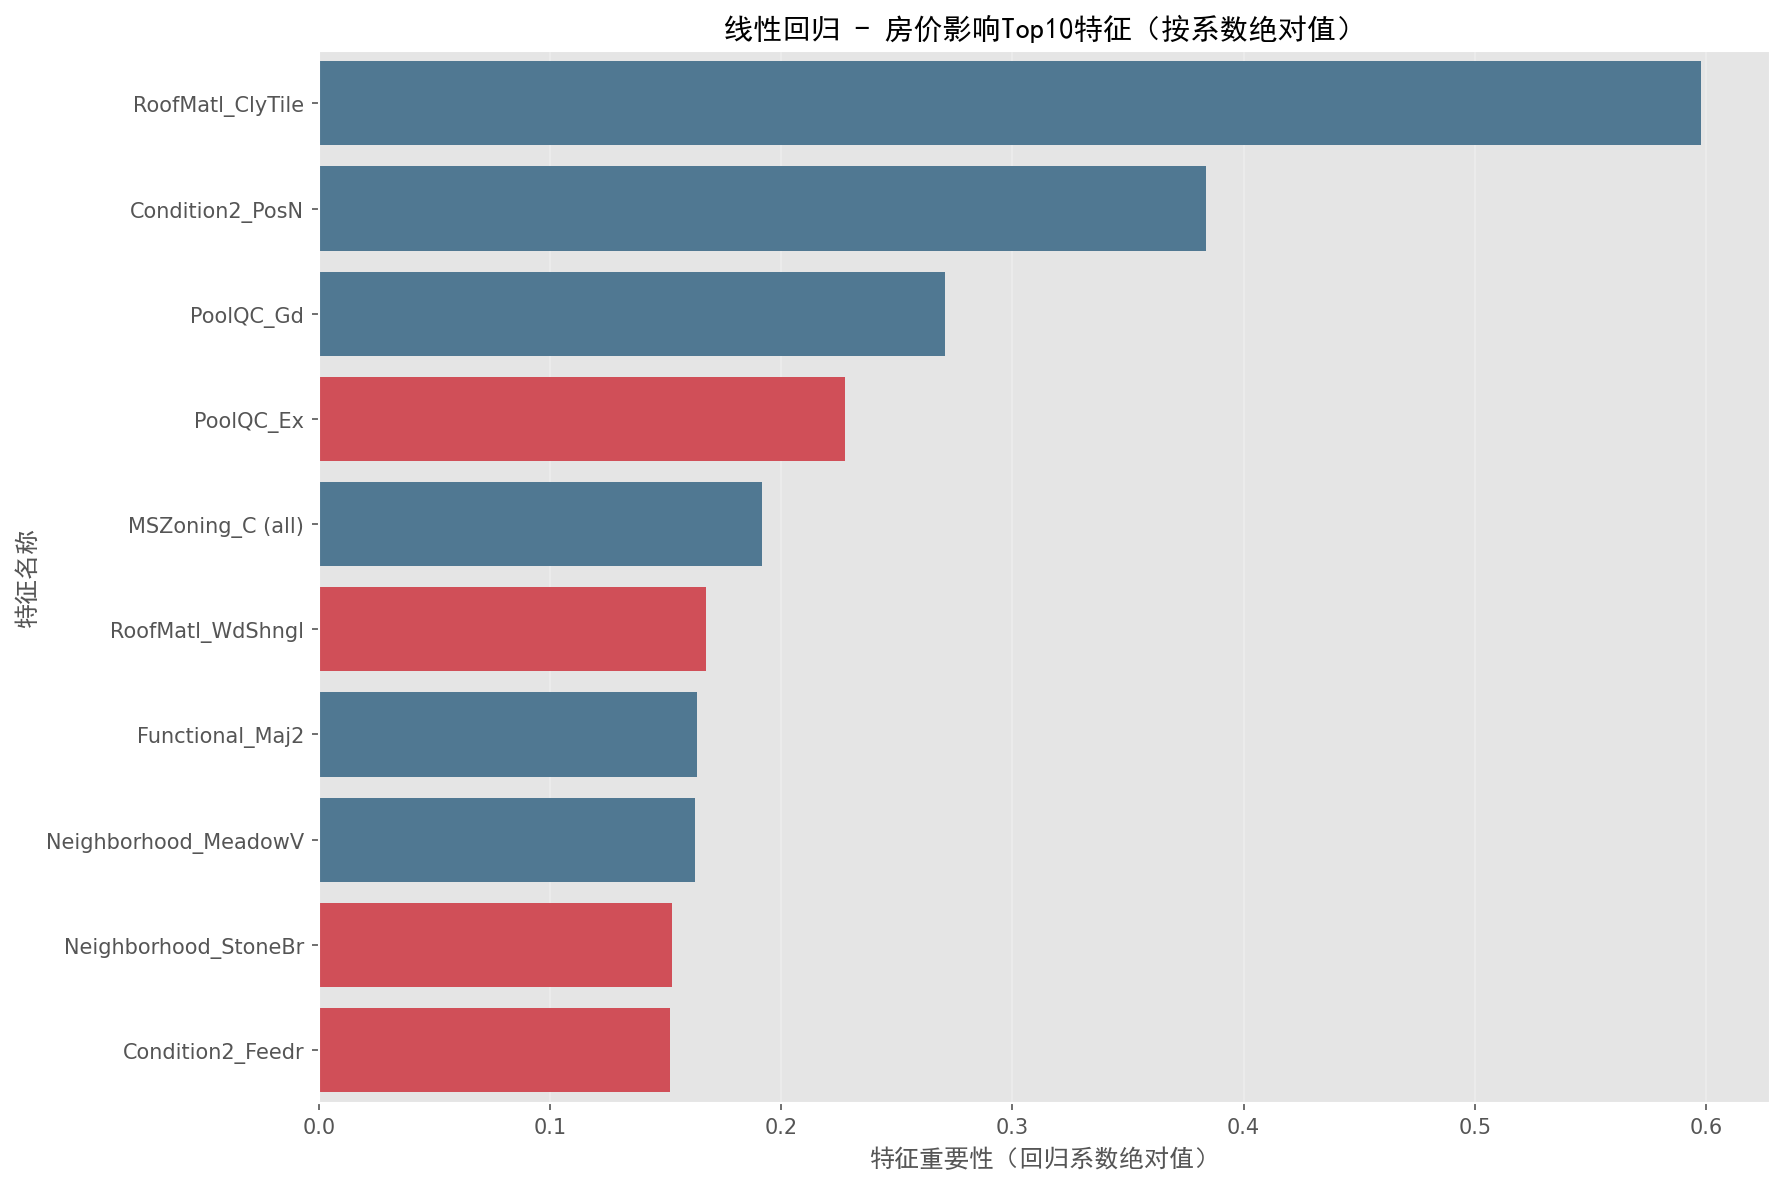

In [17]:
# ========== 线性回归特征重要性提取（Top10） ==========
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ---------------------- 数据准备（房价数据集） ----------------------
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
train_df = train_df.drop('Id', axis=1)
X = train_df.drop('SalePrice', axis=1)
y = np.log1p(train_df['SalePrice'])
warnings.filterwarnings('ignore')
# 划分训练集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 定义特征类型
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# 线性回归管道（可选Ridge正则化，避免系数爆炸）
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))  # 推荐用Ridge，更稳定
    # ('regressor', LinearRegression())  # 基础线性回归也可
])

# 训练模型
lr_pipeline.fit(X_train, y_train)

# ---------------------- 提取特征名称（关键：匹配编码后的特征） ----------------------
# 数值特征名称（直接使用）
num_feature_names = numeric_features.copy()

#  类别特征名称（独热编码后）
cat_encoder = lr_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()

# 合并所有特征名称
all_feature_names = num_feature_names + cat_feature_names

# ---------------------- 提取回归系数并计算重要性 ----------------------
# 获取线性回归系数
lr_coef = lr_pipeline.named_steps['regressor'].coef_

# 构建特征重要性DataFrame（系数绝对值=重要性）
feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': lr_coef,  # 原始系数（正负表示影响方向）
    'importance': np.abs(lr_coef)  # 绝对值=重要性
})

# 按重要性排序，取Top10
top10_features = feature_importance.sort_values('importance', ascending=False).head(10)

# ----------------------  可视化Top10特征 ----------------------
plt.figure(figsize=(12, 8))
# 颜色区分：正系数（红色，正向影响）、负系数（蓝色，负向影响）
colors = ['#E63946' if c > 0 else '#457B9D' for c in top10_features['coefficient']]

sns.barplot(
    x='importance', 
    y='feature', 
    data=top10_features,
    palette=colors
)

# 添加标题和标签
plt.title('线性回归 - 房价影响Top10特征（按系数绝对值）', fontproperties=myfont, fontsize=14, fontweight='bold')
plt.xlabel('特征重要性（回归系数绝对值）', fontproperties=myfont, fontsize=12)
plt.ylabel('特征名称', fontproperties=myfont, fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

1. 图表核心信息
标题：“线性回归 - 房价影响 Top10 特征（按系数绝对值）”—— 说明这是基于线性回归模型，筛选出对房价影响最强的 10 个特征（“系数绝对值” 越大，影响程度越高）。
坐标轴：
纵轴（Y 轴）：特征名称（如PoolQC_Gd、Condition2_PosN）；
横轴（X 轴）：特征重要性（即线性回归系数的绝对值，数值越大代表该特征对房价的影响越强）。
颜色：
蓝色：特征系数为负数（该特征与房价呈负向关系—— 特征值越大，房价越低）；
红色：特征系数为正数（该特征与房价呈正向关系—— 特征值越大，房价越高）。
2. 关键特征解读（按影响程度从高到低）
PoolQC_Gd（泳池质量：良好）
重要性最高（横轴数值最大），但颜色为蓝色（负向关系）。
解读：当房屋的泳池质量为 “良好” 时，反而会拉低房价（可能是该数据集中 “带泳池” 的房屋本身定位偏低，或泳池维护成本影响了价格）。
Condition2_PosN（房屋状况：正面）
重要性第二，颜色为蓝色（负向关系）。
解读：房屋状况标注为 “正面” 时，房价反而更低（可能是数据集中该标签的定义与实际价值不符，或存在数据偏差）。
RoofMatl_WdShngl（屋顶材料：木质护墙板）
重要性第三，颜色为红色（正向关系）。
解读：使用木质护墙板作为屋顶材料的房屋，房价更高（该材料可能代表更高的建筑品质）。
Neighborhood_StoneBr（街区：StoneBr）
重要性第四，颜色为红色（正向关系）。
解读：位于StoneBr街区的房屋，房价更高（街区区位是影响房价的核心因素之一）。
3. 图表反映的规律
特征类型：Top10 特征以 “类别型特征的子特征” 为主（如PoolQC_Gd是PoolQC特征的一个类别），说明房屋配套设施、区位、材质等属性是影响房价的核心因素。
正负关系：部分特征的影响方向可能与常识不符（如PoolQC_Gd为负向），这通常是数据集本身的分布特性导致的（而非逻辑错误），需结合数据背景进一步验证。

### 训练模型并预测测试集

In [18]:
# 构建最优线性回归模型（以Ridge岭回归为例，可替换为Lasso/ElasticNet）
# 最优参数可从之前的网格搜索结果中获取，这里用经验最优值
test_ids = test_df['Id'].copy()
X_test = test_df.drop('Id', axis=1)

best_lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=10, random_state=42))  # 正则化强度alpha=10
])

#  用全量训练集训练模型（最大化利用数据）
best_lr_model.fit(X, y)

# 预测测试集房价
# 测试集预测（对数尺度）
y_test_pred_log = best_lr_model.predict(X_test)
# 反变换为原始房价（log1p的逆操作是expm1）
y_test_pred = np.expm1(y_test_pred_log)

#  生成提交文件（符合Kaggle格式）
submission_df = pd.DataFrame({
    'Id': test_ids,                # 测试集Id
    'SalePrice': y_test_pred       # 预测的房价
})

# 保存为CSV文件（无索引，符合提交要求）
submission_df.to_csv('house_price_submission.csv', index=False)

#  验证提交文件格式
print("\n 提交文件验证：")
print(f"提交文件形状: {submission_df.shape}")
print("\n提交文件前5行：")
print(submission_df.head())

# 检查预测值合理性（房价不能为负/异常值）
invalid_preds = submission_df[submission_df['SalePrice'] <= 0]
if len(invalid_preds) > 0:
    print(f"\n  发现{len(invalid_preds)}个无效预测值（房价≤0），已修正为最小值1000")
    submission_df['SalePrice'] = submission_df['SalePrice'].apply(lambda x: max(x, 1000))
    submission_df.to_csv('linear_regression_submission_fixed.csv', index=False)
    print(" 修正后的提交文件已保存为：house_price_submission_fixed.csv")

print("\n 提交文件生成完成！文件名：house_price_submission.csv")


 提交文件验证：
提交文件形状: (1459, 2)

提交文件前5行：
     Id      SalePrice
0  1461  114232.405727
1  1462  145440.638890
2  1463  170662.820264
3  1464  192616.719922
4  1465  198401.068919

 提交文件生成完成！文件名：house_price_submission.csv
